In [1]:
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel, LSTMModel, DecoupledGCNModel
from src.dataloading.crossvalidation.crossvalidationepiconfig import CrossValidationEpiConfig
from src.dataloading.crossvalidation.epifold import EpiFold, FoldCollection


# ── base config: defines disease, features, pipeline settings ────────────
base_config = EpiConfig(
    disease           = 'covid_daily',
    country           = 'netherlands',
    level             = 'lau',
    horizon_leadtime  = 7,
    sequence_length   = 14,
    temporal_frequency= 'd',
    time_index_d      = True,

    # these dates will be overridden per fold — just need to be wide enough
    # for the global load_raw to capture everything
    min_date          = '2021-07-01',
    max_date          = '2022-04-10',

    feature_popsize   = False,
    feature_popdens   = True,
    log_transform     = ['incidence'],
)

# define folds manually as a list of (min_date, trainval_split, valtest_split, max_date)
# each window is 61 days: 53 train, 7 val, 1 test
# step ~4 weeks between fold starts to get meaningful coverage

manual_splits = [
    ('2021-07-01', '2021-08-23', '2021-09-14', '2021-09-28'),  # 53 train, 22 val, 14 test
    ('2021-07-29', '2021-09-20', '2021-10-12', '2021-10-26'),
    ('2021-08-26', '2021-10-18', '2021-11-09', '2021-11-23'),
    ('2021-09-23', '2021-11-15', '2021-12-07', '2021-12-21'),
    ('2021-10-21', '2021-12-13', '2022-01-04', '2022-01-18'),
    ('2021-11-18', '2022-01-10', '2022-02-01', '2022-02-15'),
    ('2021-12-16', '2022-02-07', '2022-03-01', '2022-03-15'),
    ('2022-01-13', '2022-03-07', '2022-03-29', '2022-04-10'),
]

In [2]:
from src.dataloading.crossvalidation.epifold import EpiFold, FoldCollection
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from dataclasses import replace

# load raw once
global_orch = EpiDataOrchestrator(base_config).load()
shared_raw  = global_orch.data_raw

folds = []
for fold_idx, (min_date, trainval, valtest, max_date) in enumerate(manual_splits):
    fold_config = replace(
        base_config,
        min_date       = min_date,
        split_trainval = trainval,
        split_valtest  = valtest,
        max_date       = max_date,
    )

    fold_orch = (
        EpiDataOrchestrator.from_raw(fold_config, shared_raw)
        .harmonize()
        .process()
        .build_features()
        .normalize()
        .finalize()
    )

    folds.append(EpiFold(
        fold_idx = fold_idx,
        metadata = {
            'min_date':       min_date,
            'trainval_split': trainval,
            'valtest_split':  valtest,
            'max_date':       max_date,
        },
        epiconfig  = fold_config,
        data_orch  = fold_orch,
    ))

print(f"Built {len(folds)} folds")
for f in folds:
    print(f"  fold {f.fold_idx}: train {f.metadata['min_date']} → {f.metadata['trainval_split']} | test {f.metadata['max_date']}")

Built 8 folds
  fold 0: train 2021-07-01 → 2021-08-23 | test 2021-09-28
  fold 1: train 2021-07-29 → 2021-09-20 | test 2021-10-26
  fold 2: train 2021-08-26 → 2021-10-18 | test 2021-11-23
  fold 3: train 2021-09-23 → 2021-11-15 | test 2021-12-21
  fold 4: train 2021-10-21 → 2021-12-13 | test 2022-01-18
  fold 5: train 2021-11-18 → 2022-01-10 | test 2022-02-15
  fold 6: train 2021-12-16 → 2022-02-07 | test 2022-03-15
  fold 7: train 2022-01-13 → 2022-03-07 | test 2022-04-10



==                  gcn_g1_f0                   ==

==                  gcn_g2_f0                   ==

==                  gcn_g7_f0                   ==

==                  gcn_g16_f0                  ==

==                   lstm_f0                    ==
model_hparams_set ✓
global_hparams_set ✓
model_hparams_set ✓
global_hparams_set ✓
model_hparams_set ✓
global_hparams_set ✓
model_hparams_set ✓
global_hparams_set ✓
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(342, 6, 14), y=(342, 1), edge_index=(2, 342), edge_weight=(342,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.4767   |   0.5158   |    v     |           |
|  002  |   1.1589   |   0.6268   |          |   1/20    |
|  003  |   0.9681   |   0.5169   |          |   2/20    |
|  004  |   0.8968   |   0.4768   |    v     |           |
|  005  |   0.8574   |   0.4588   |    v     |           |
|  006  |   0.8240   |

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4274
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 471.32it/s]

Test loss: 0.4075
forecasted ✓
Dataloader Snapshot: GraphData(x=(342, 6, 14), y=(342, 1), edge_index=(2, 1258), edge_weight=(1258,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |


...

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4443
trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 1405.24it/s]


Test loss: 3.0155
forecasted ✓


computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2052/2052 [00:03<00:00, 548.95it/s]


fold 7 done

All 8 folds evaluated


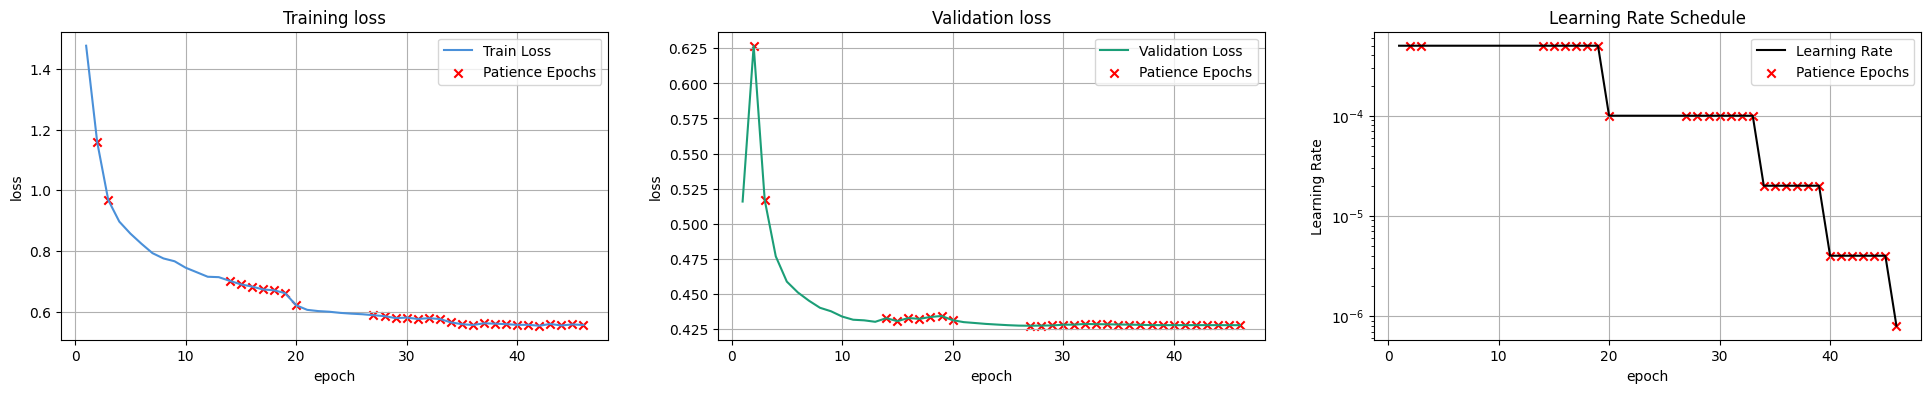

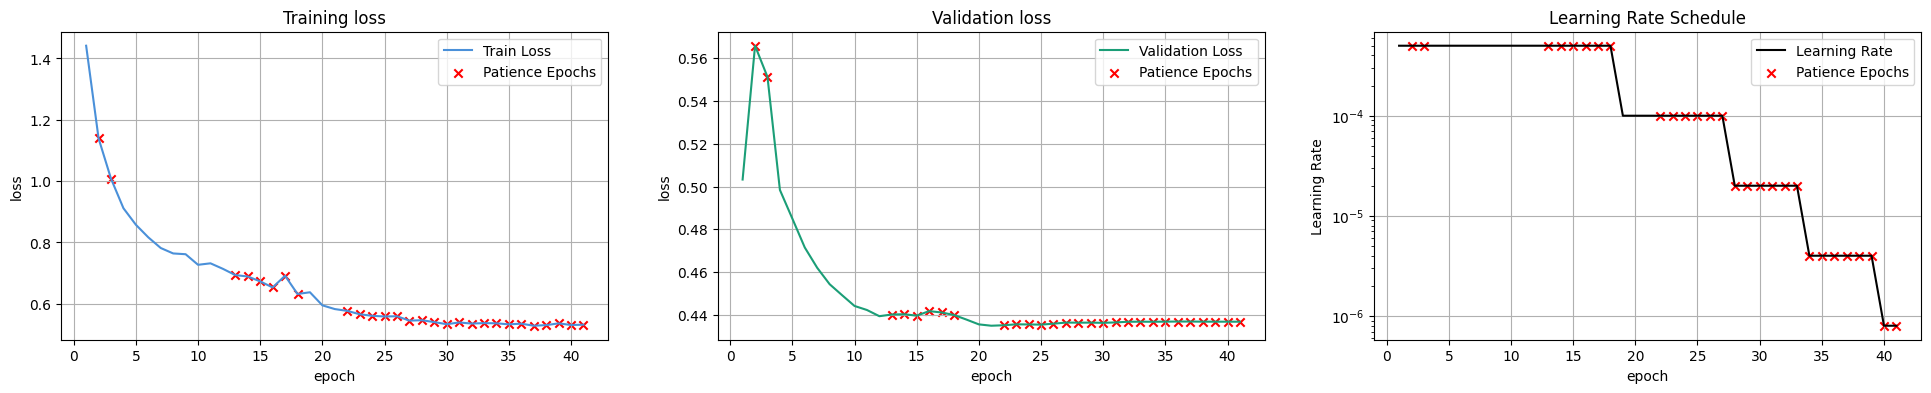

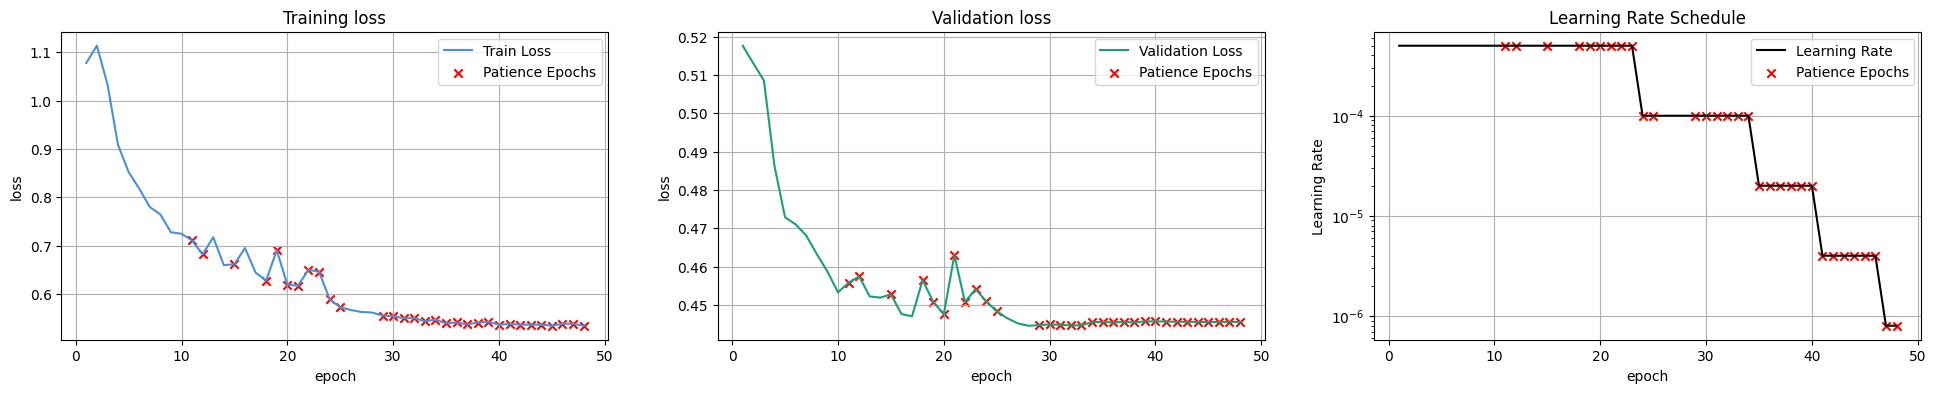

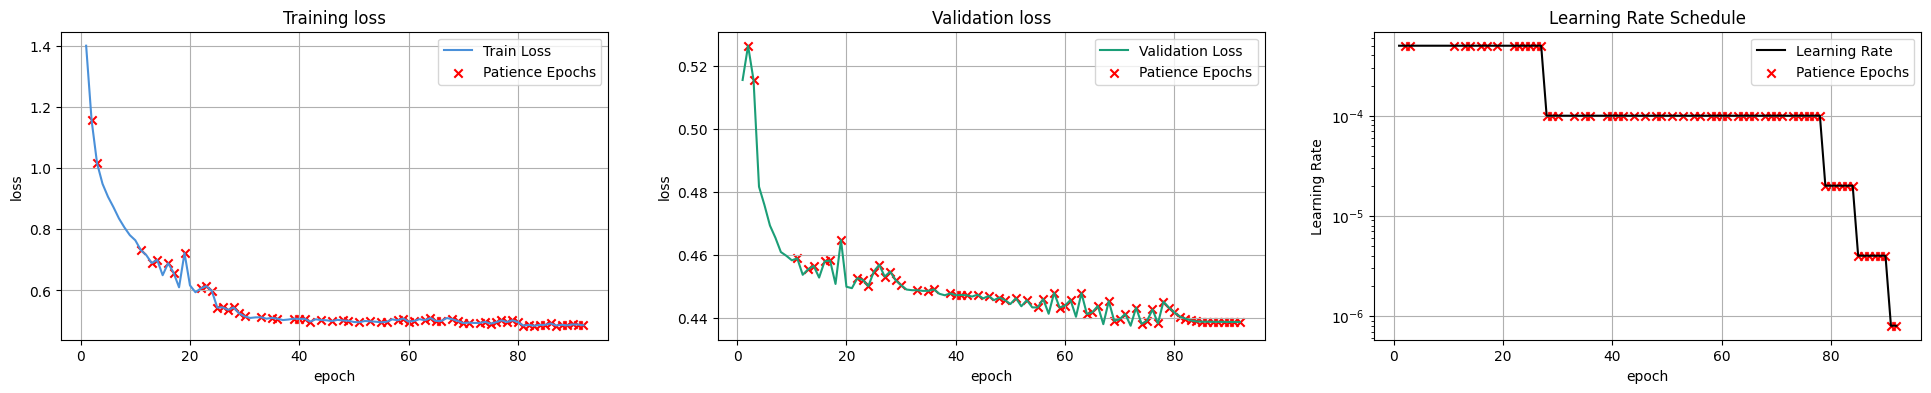

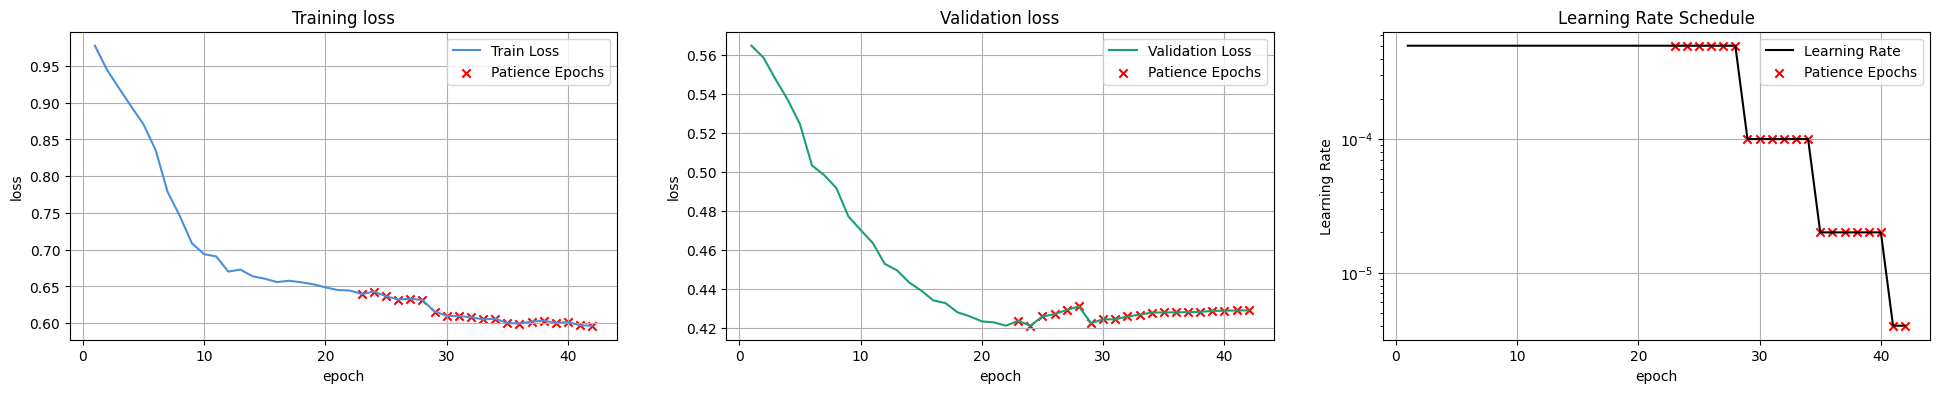

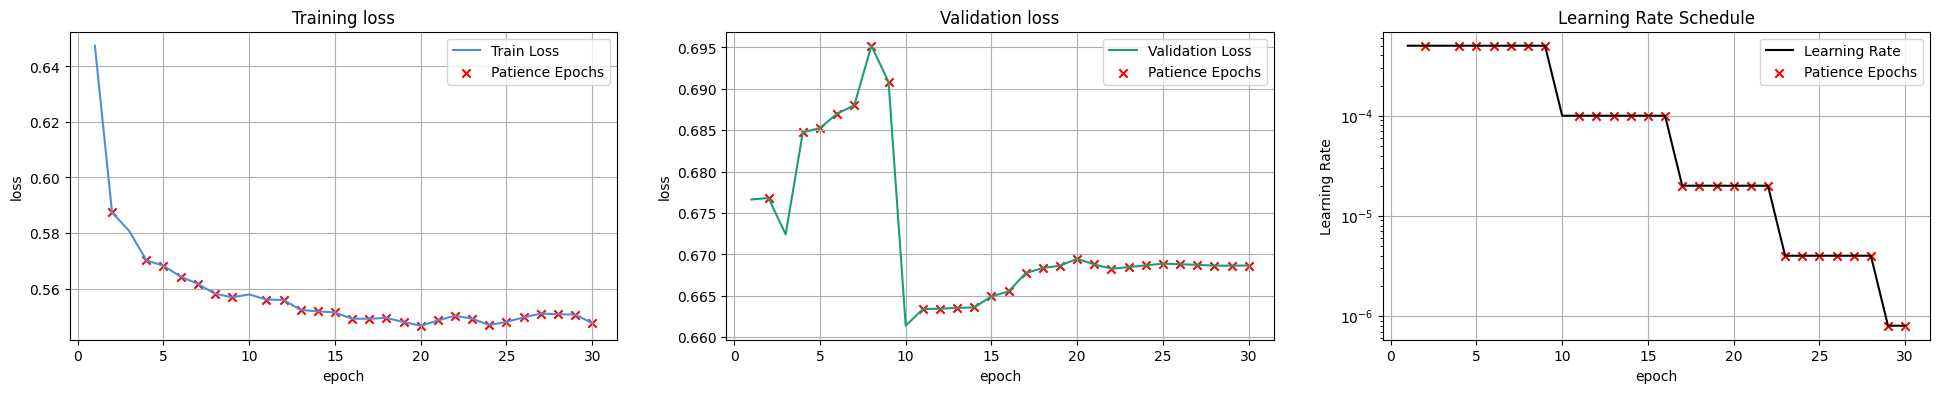

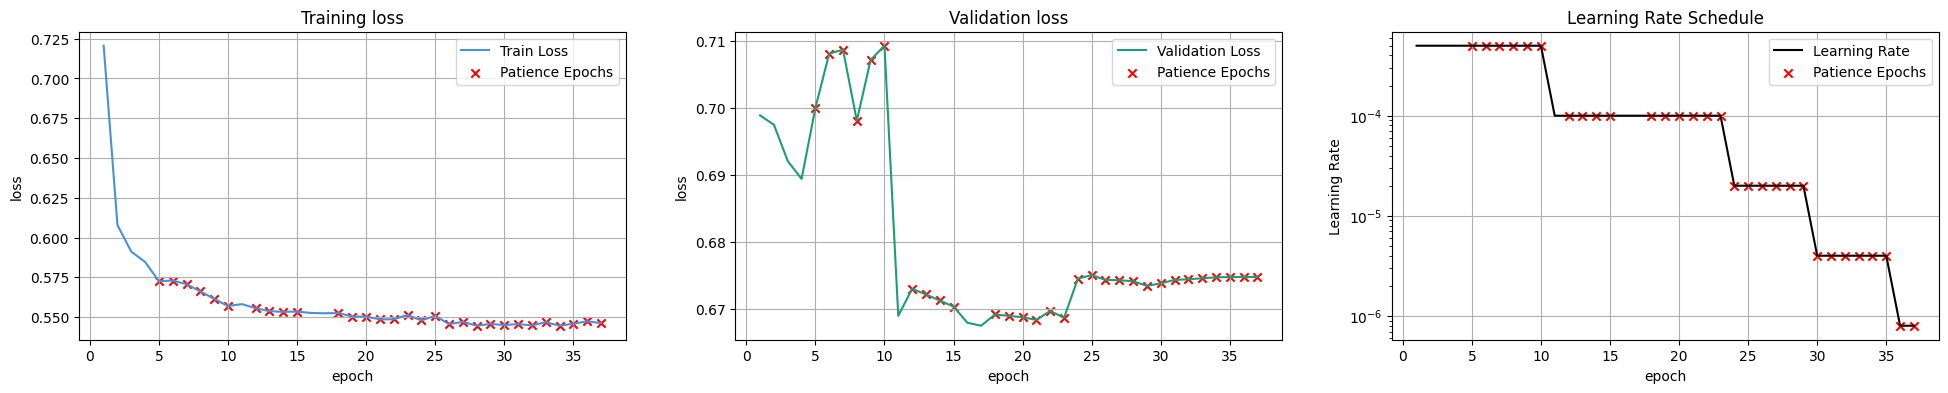

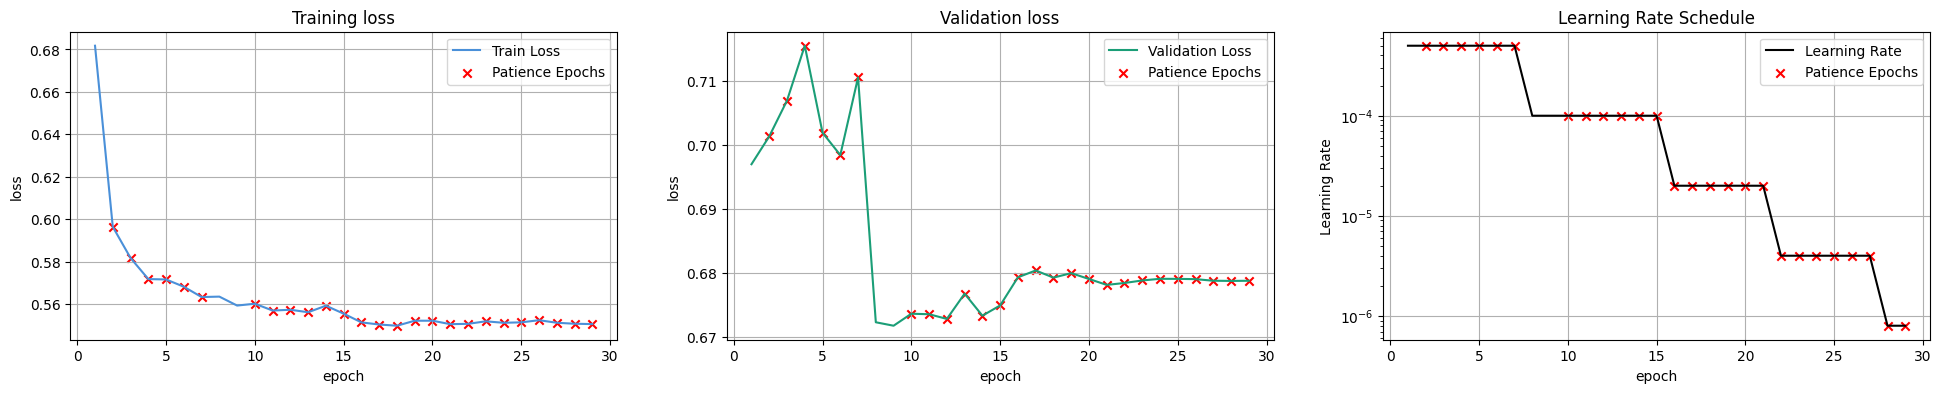

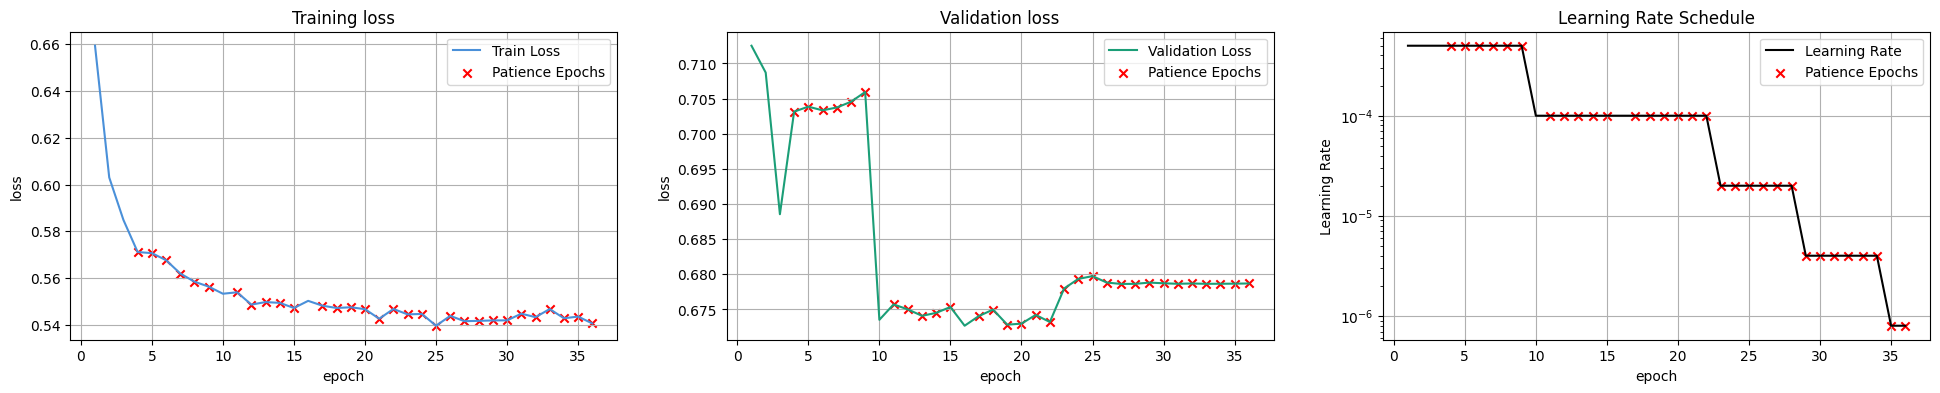

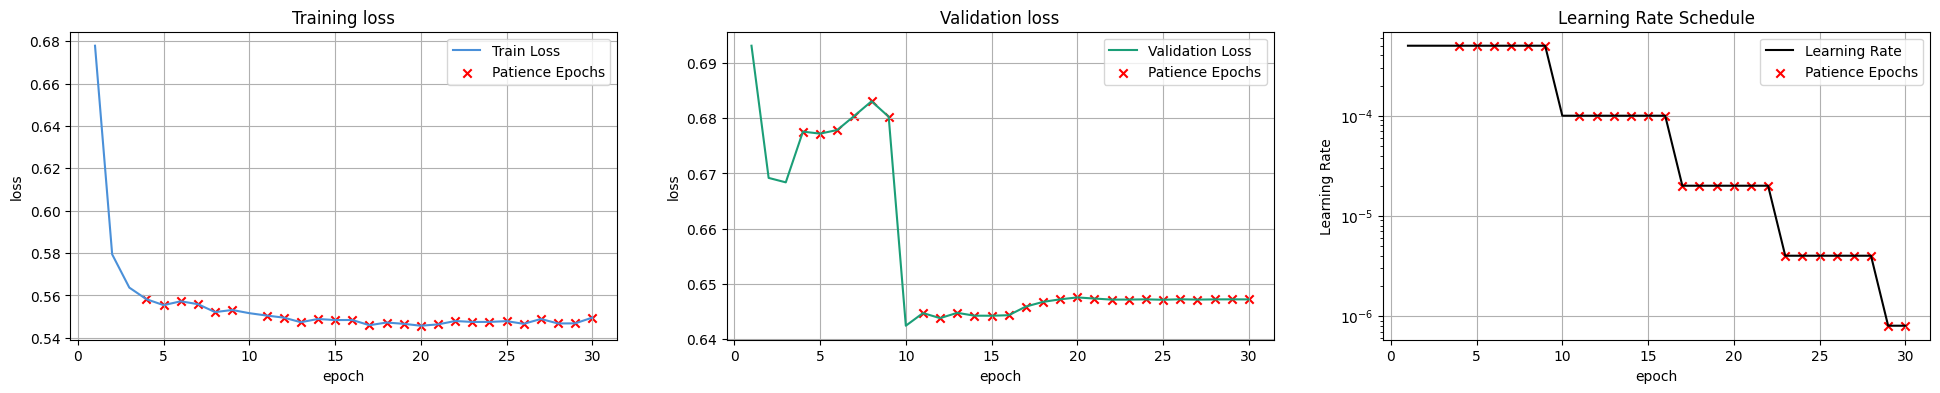

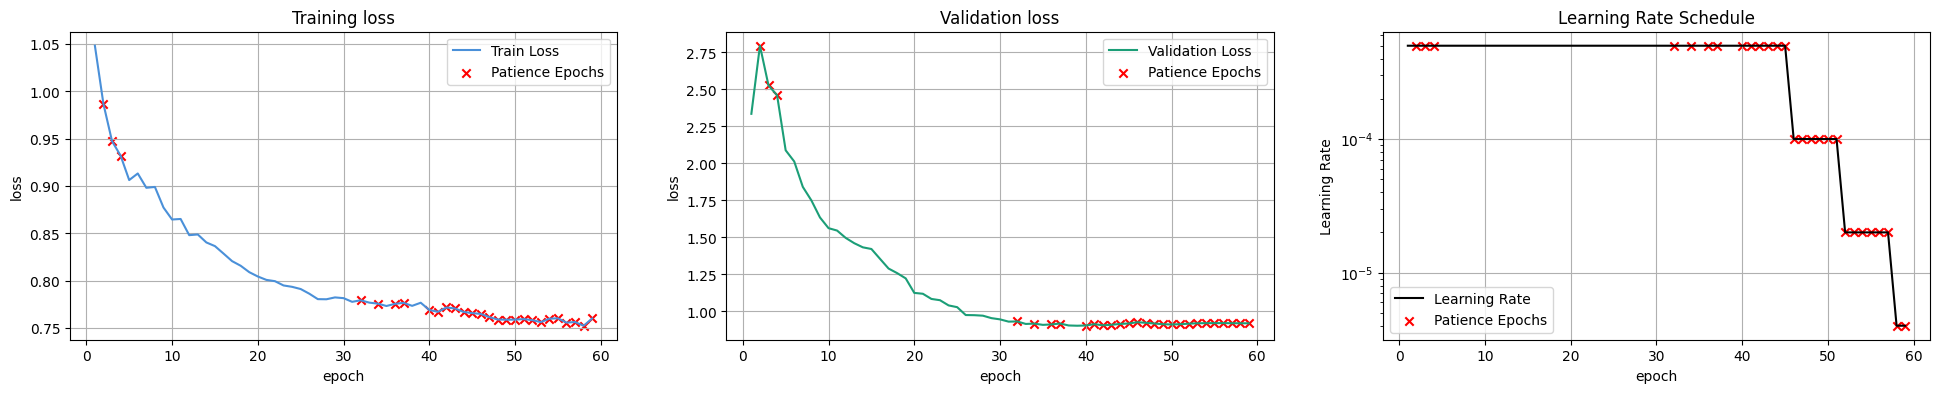

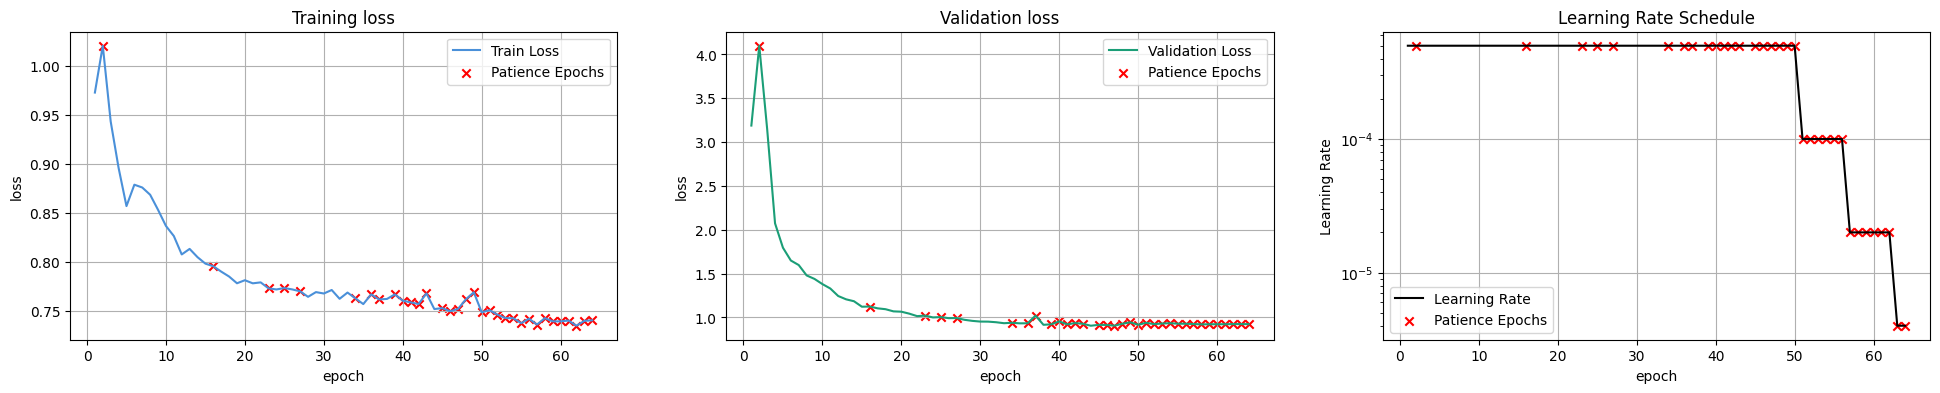

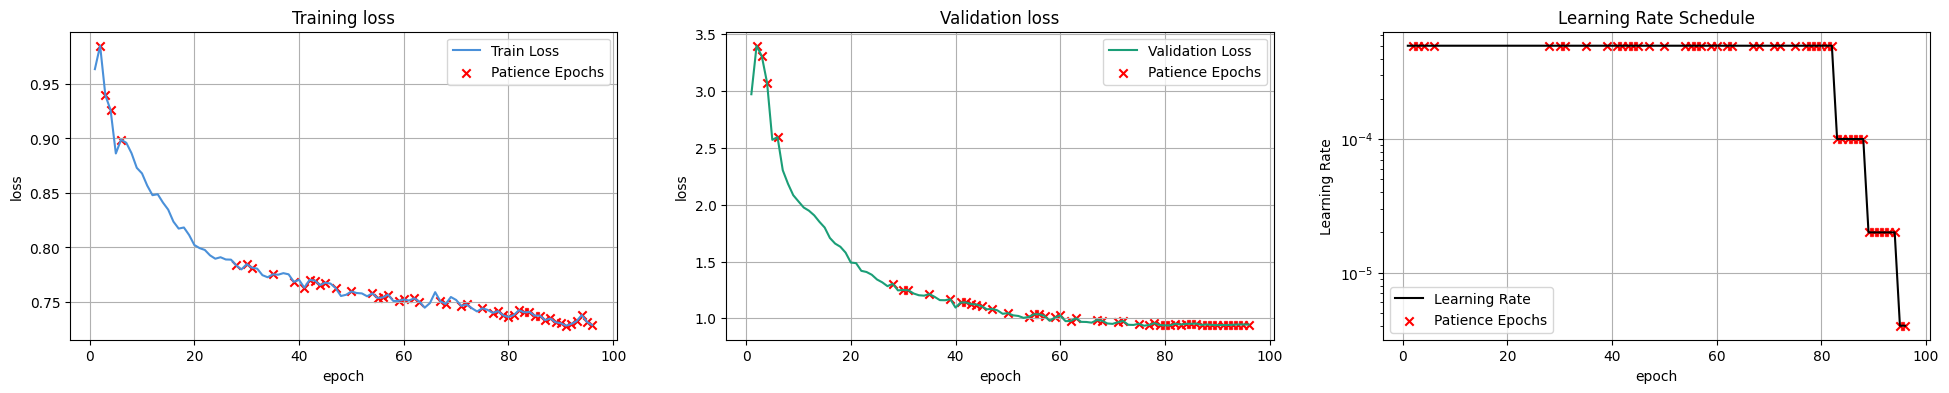

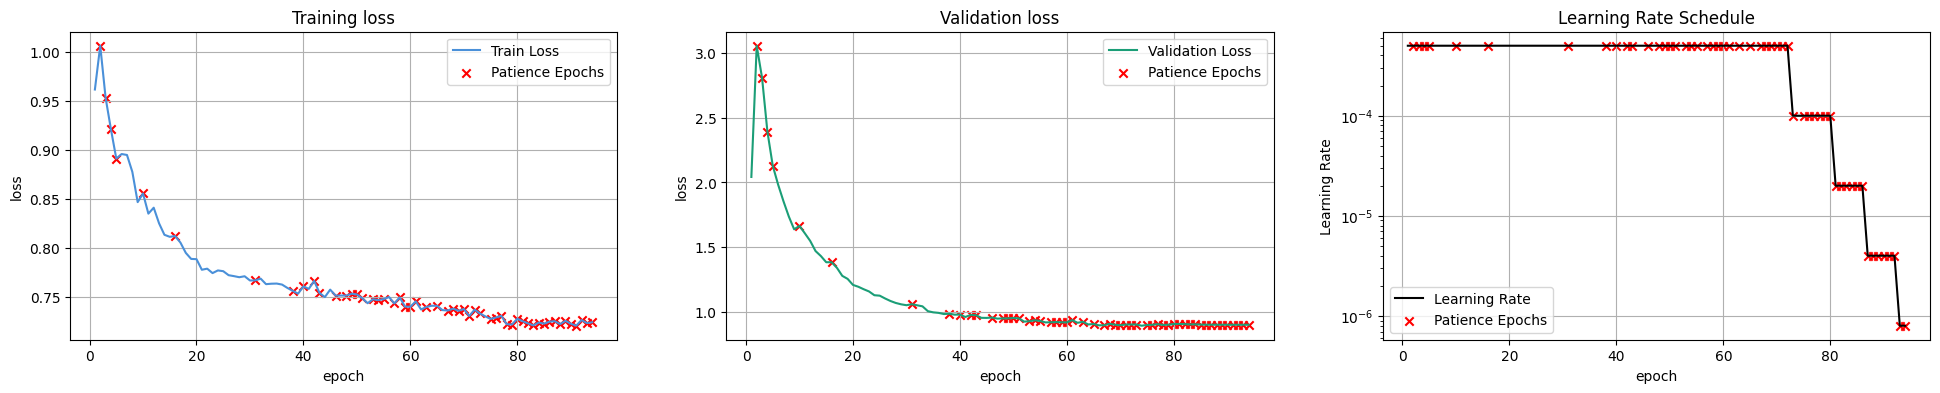

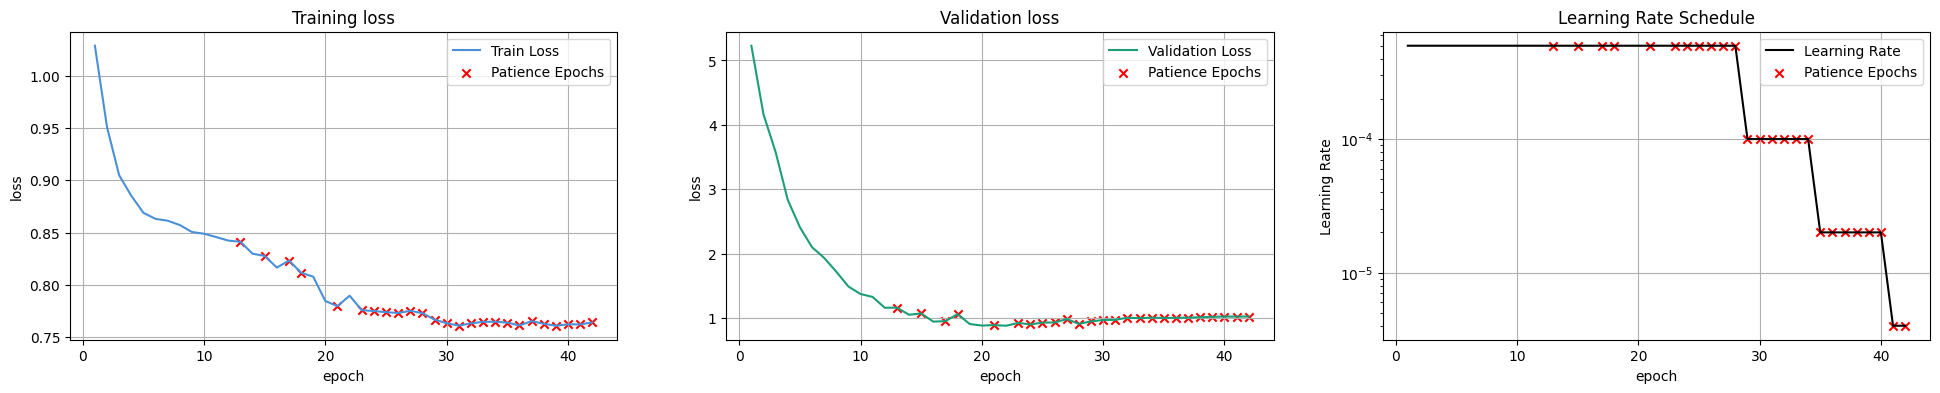

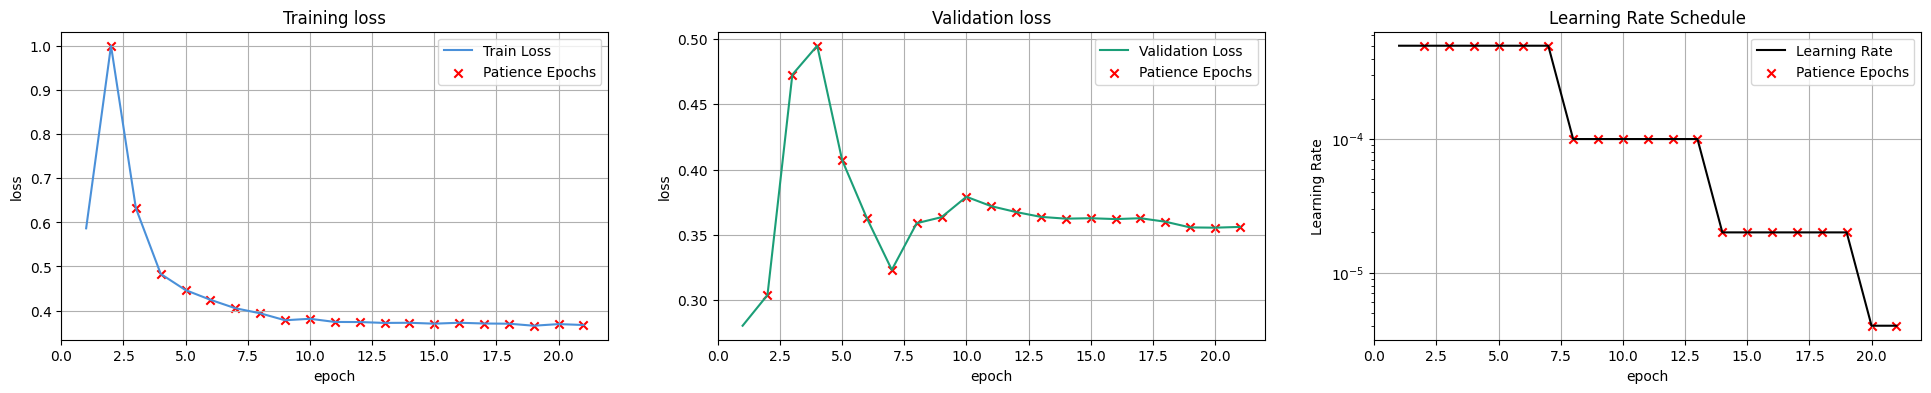

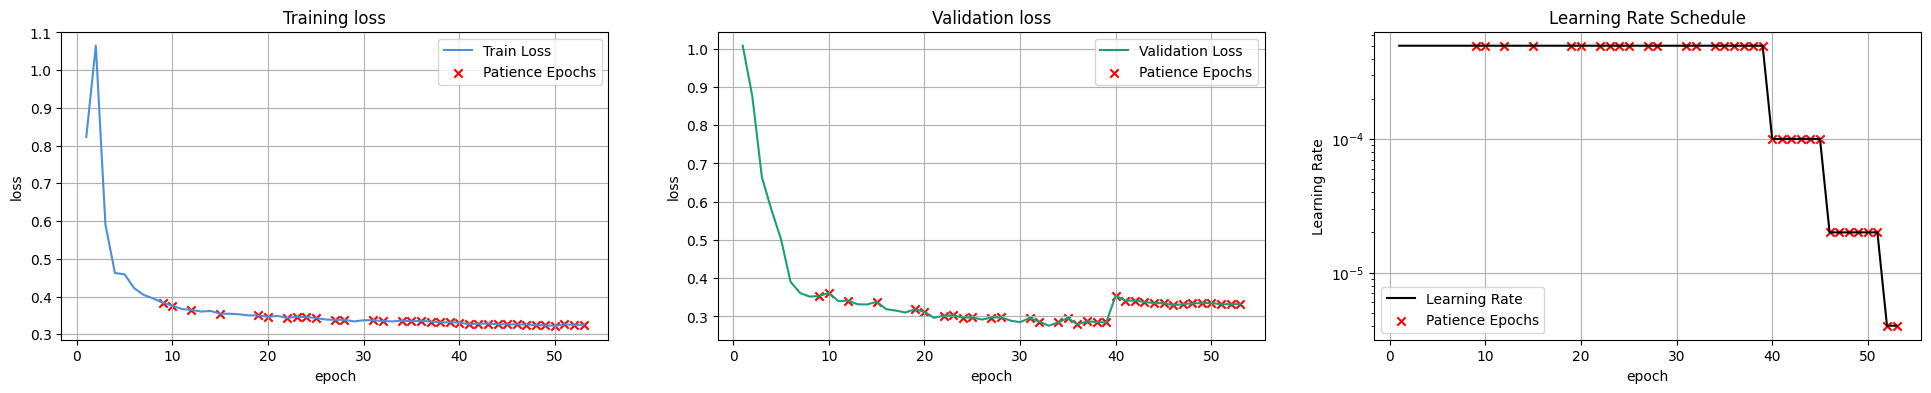

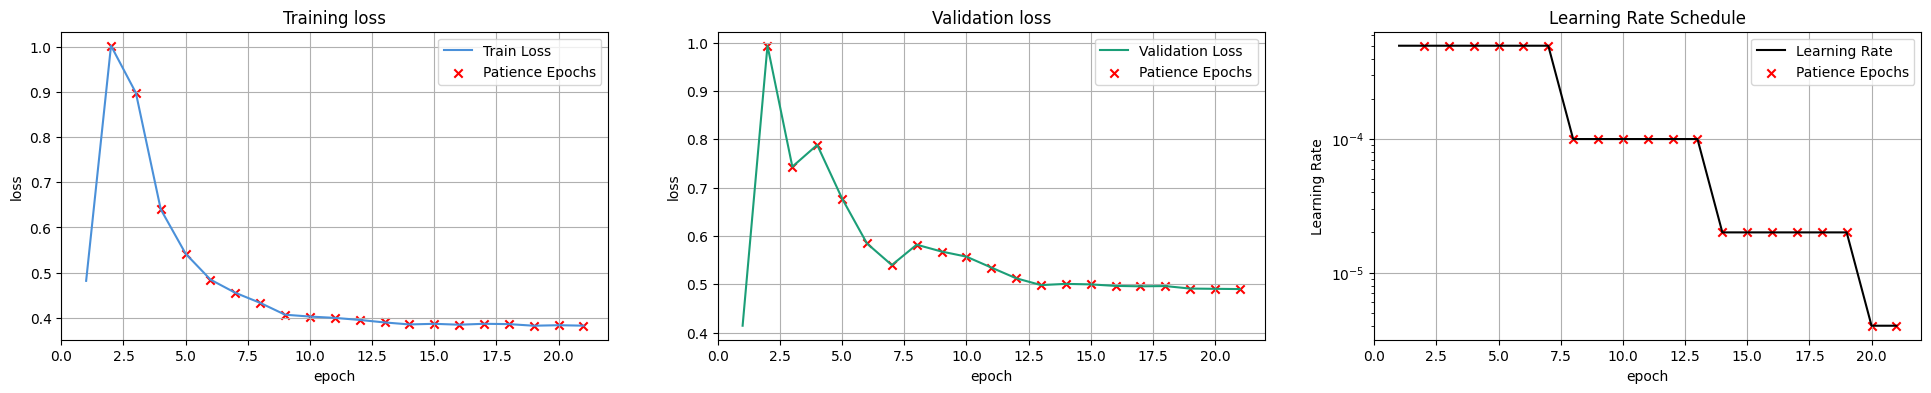

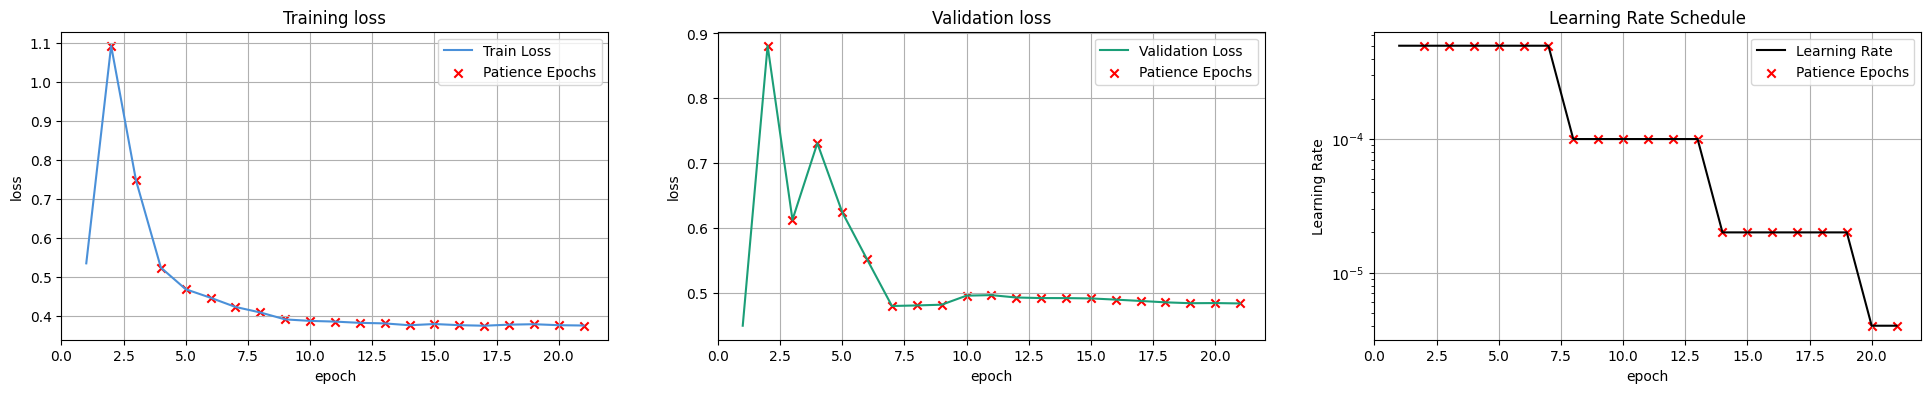

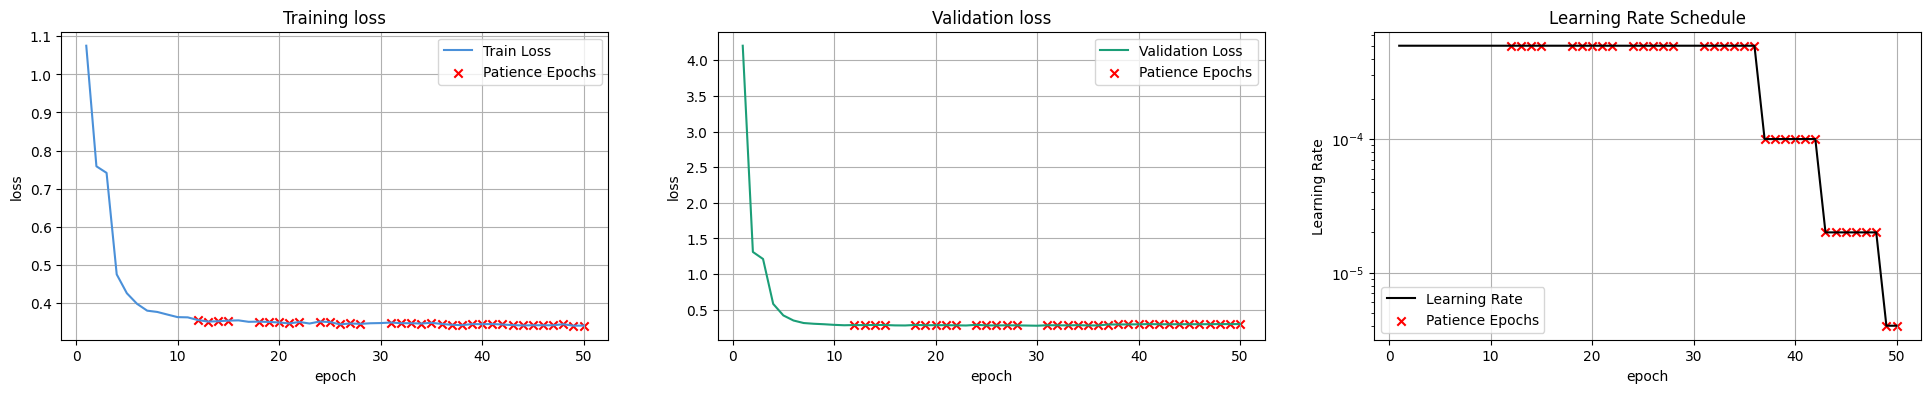

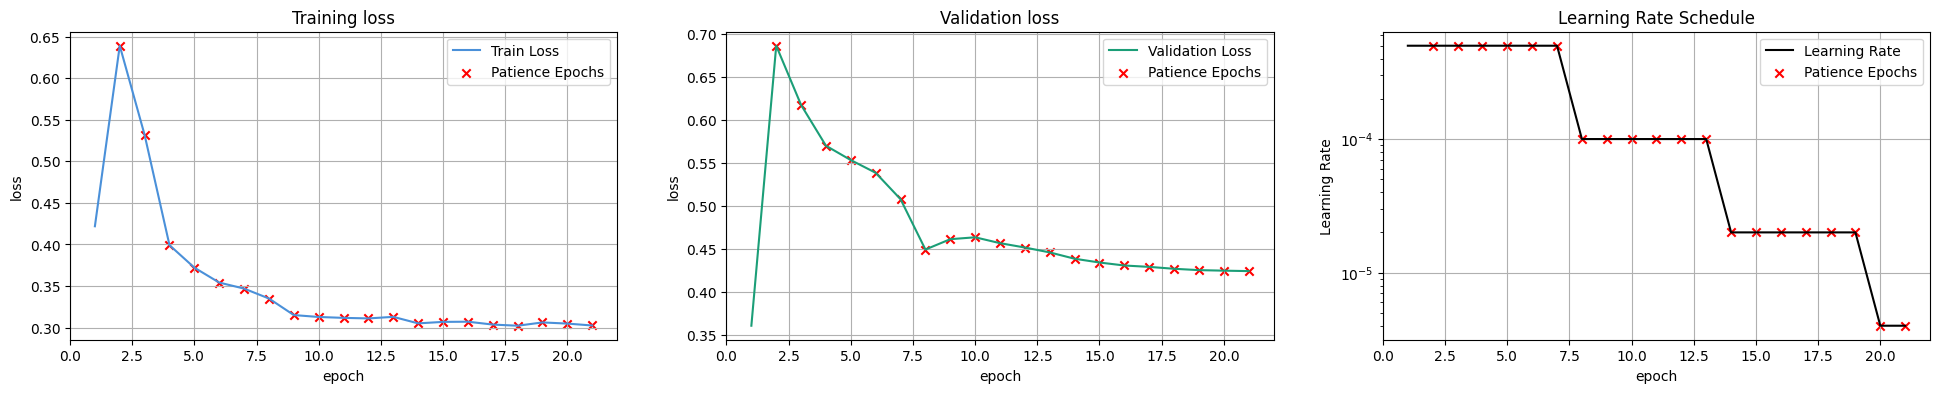

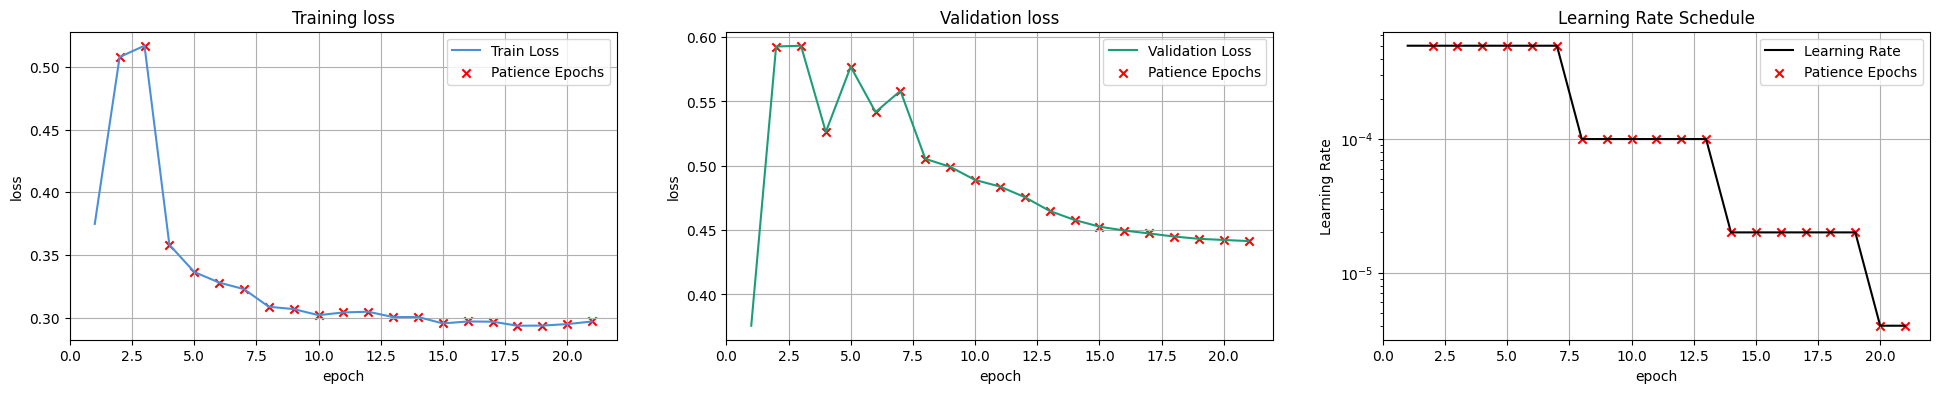

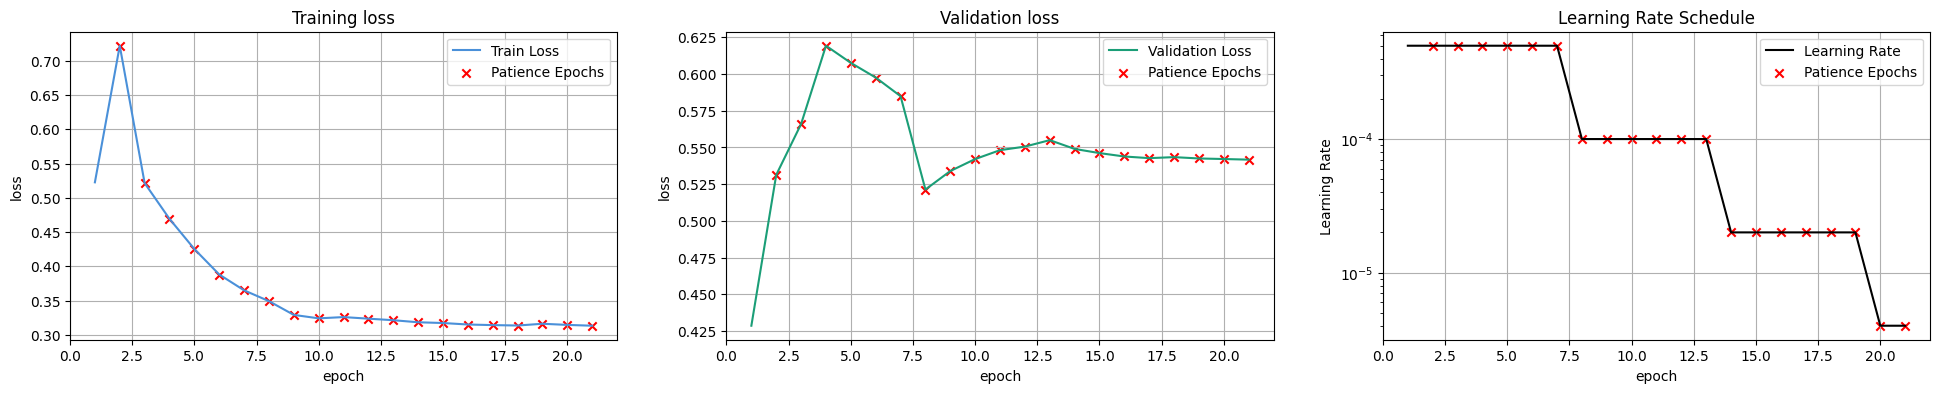

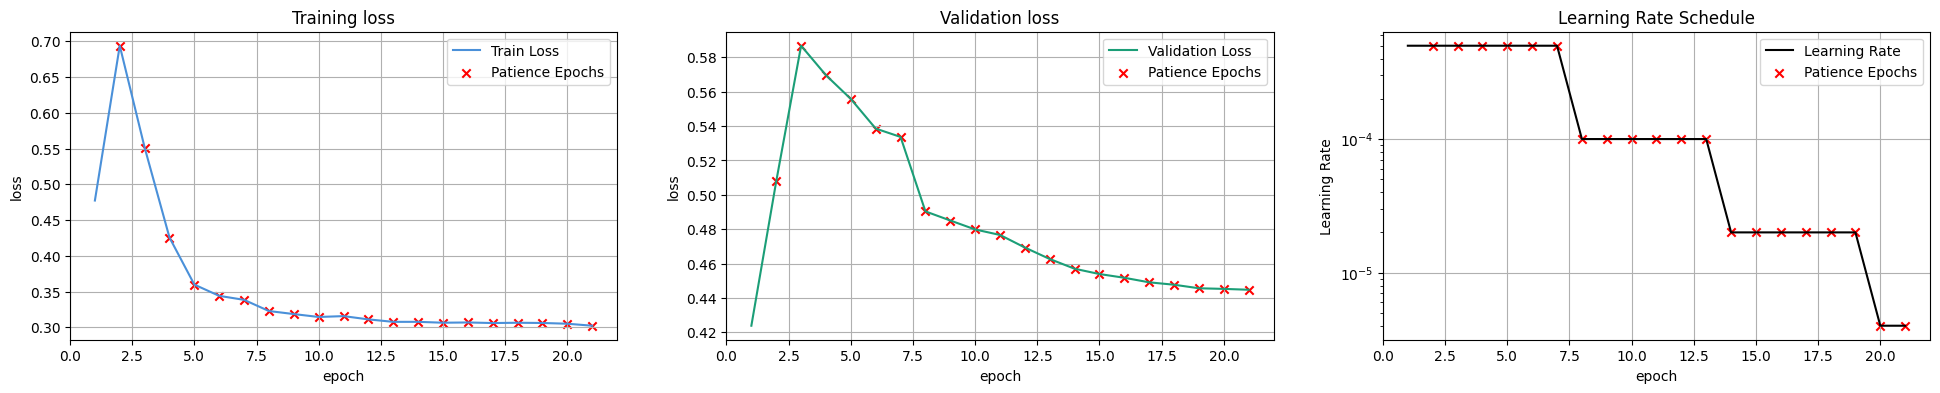

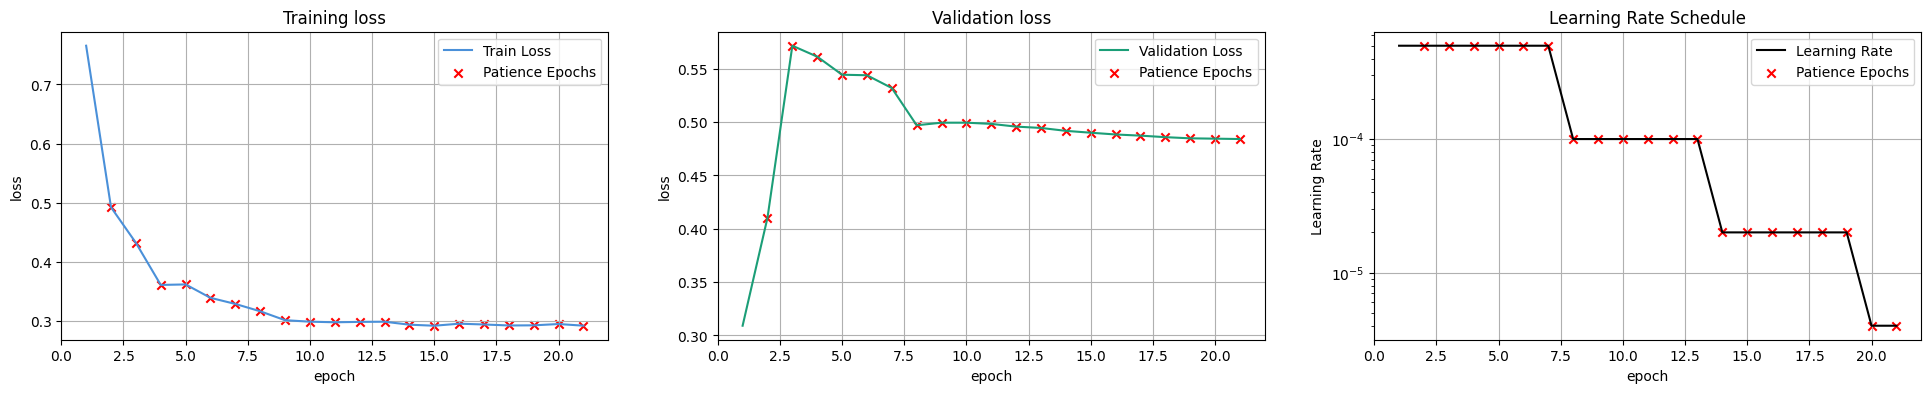

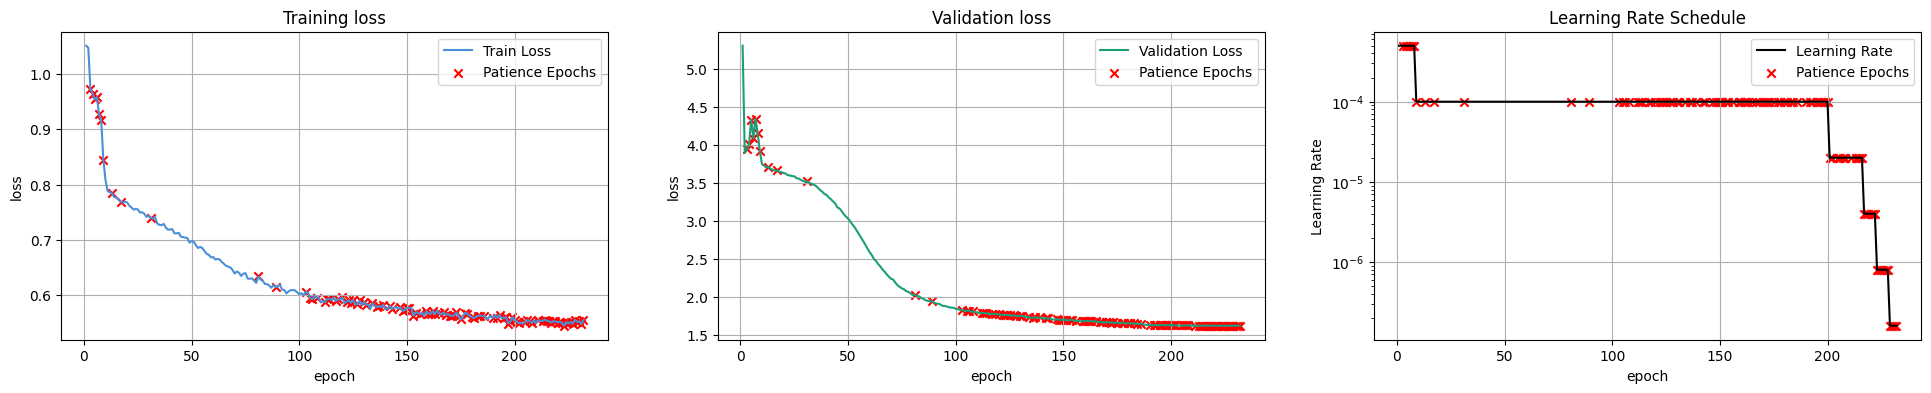

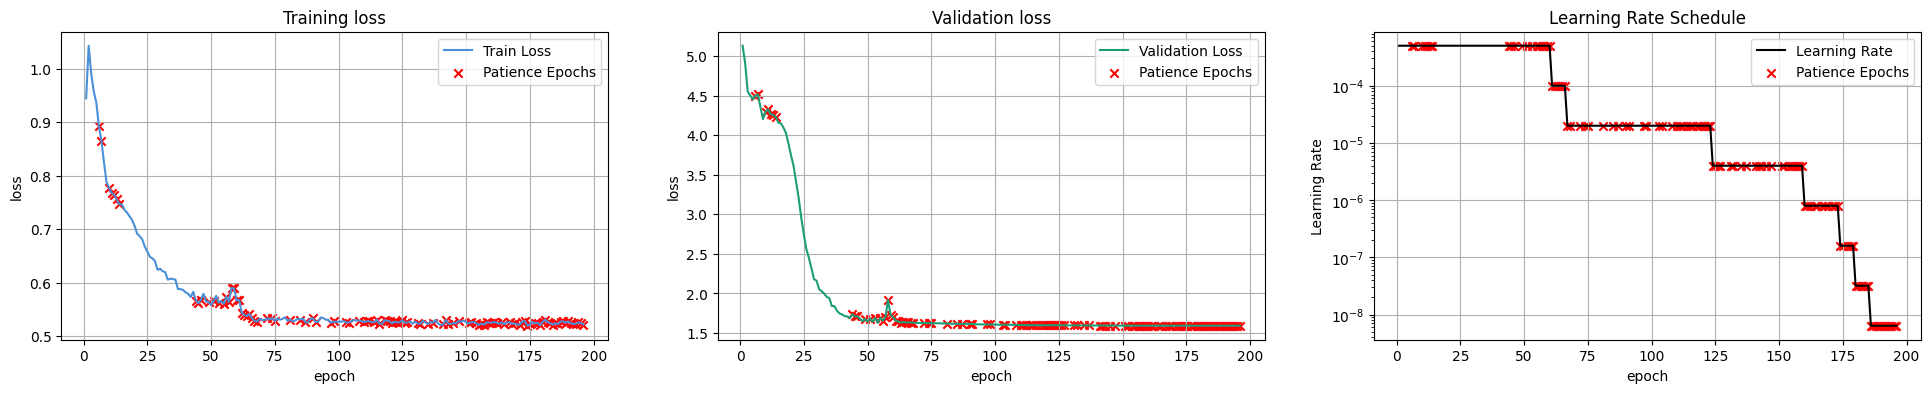

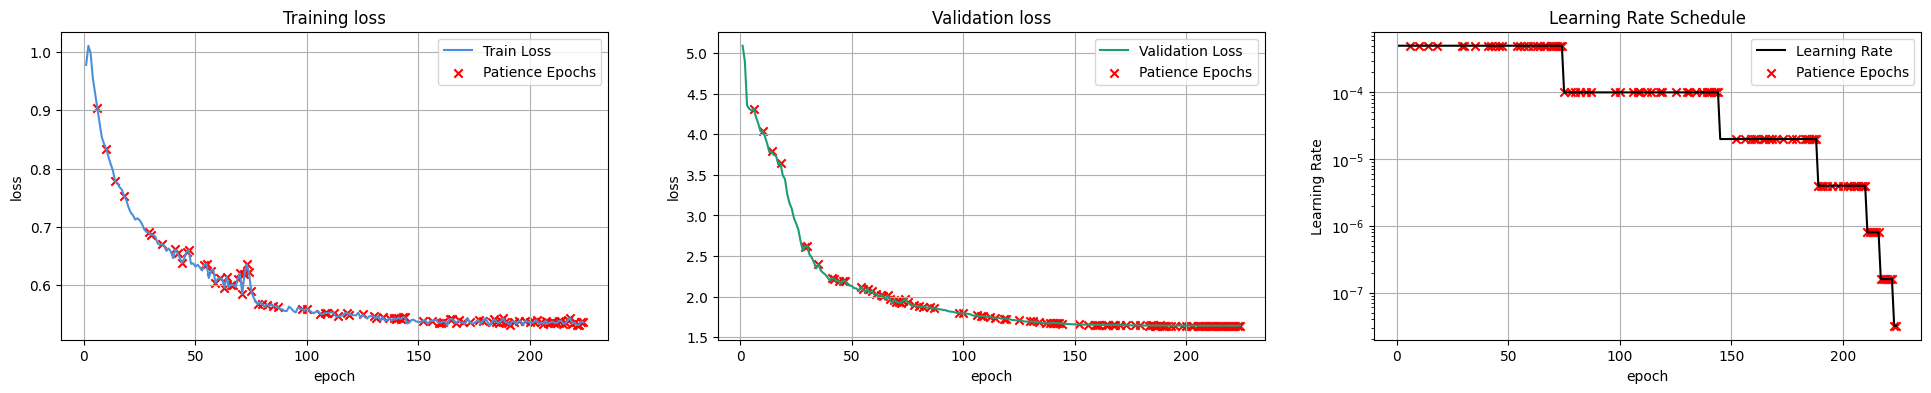

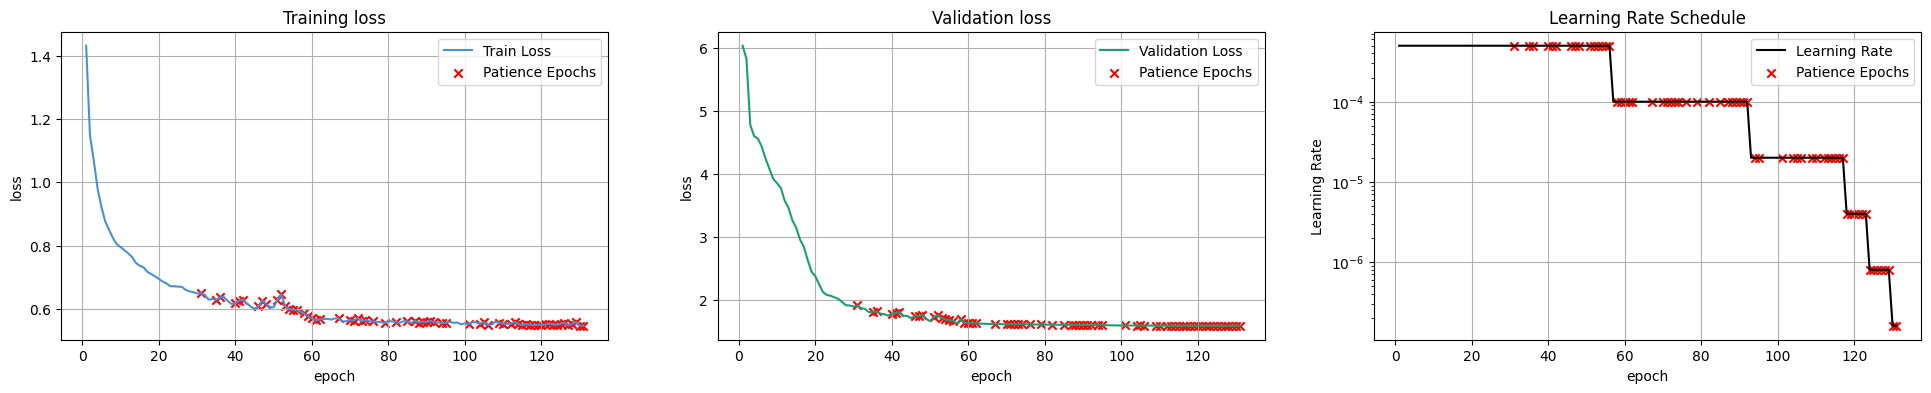

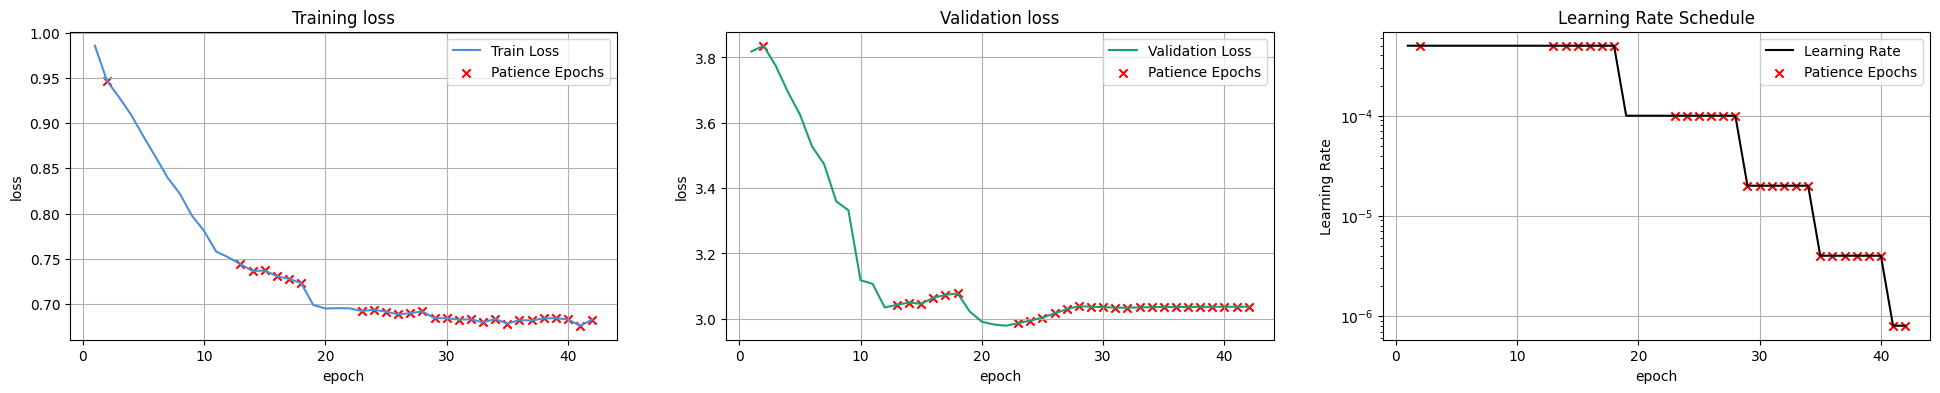

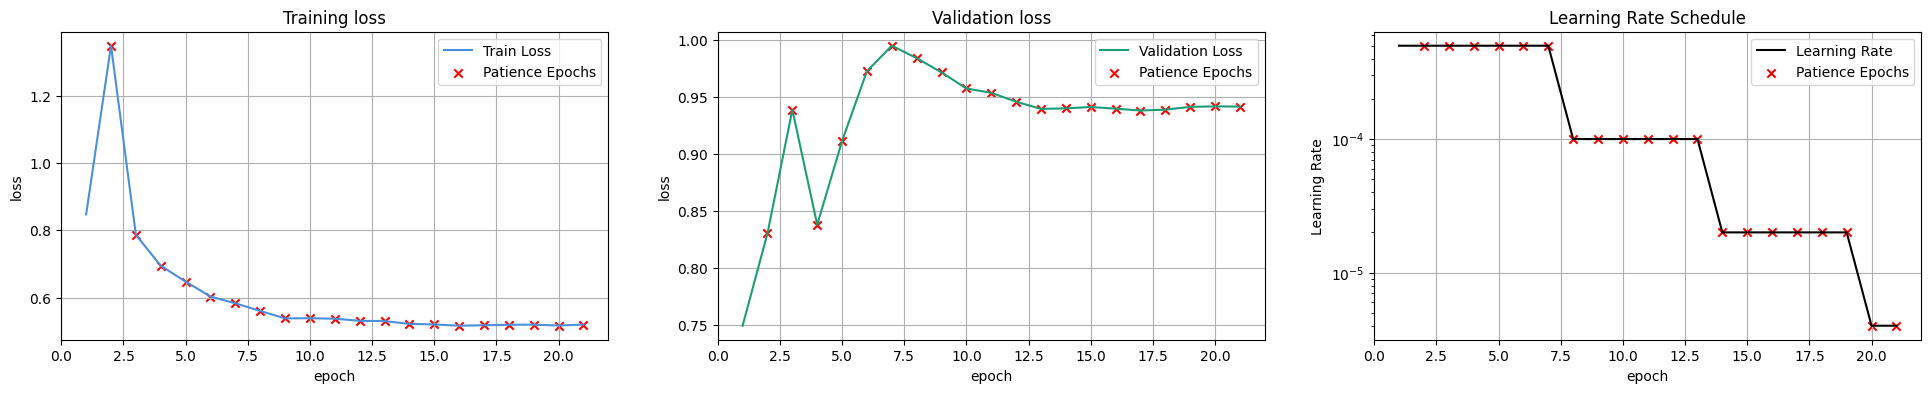

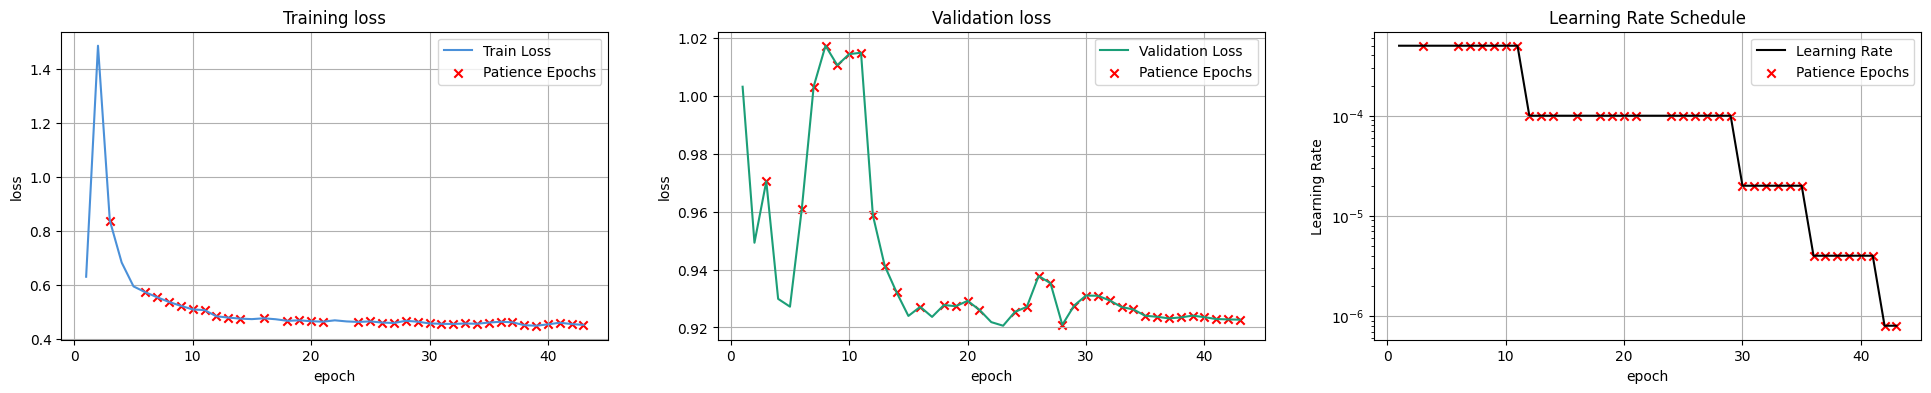

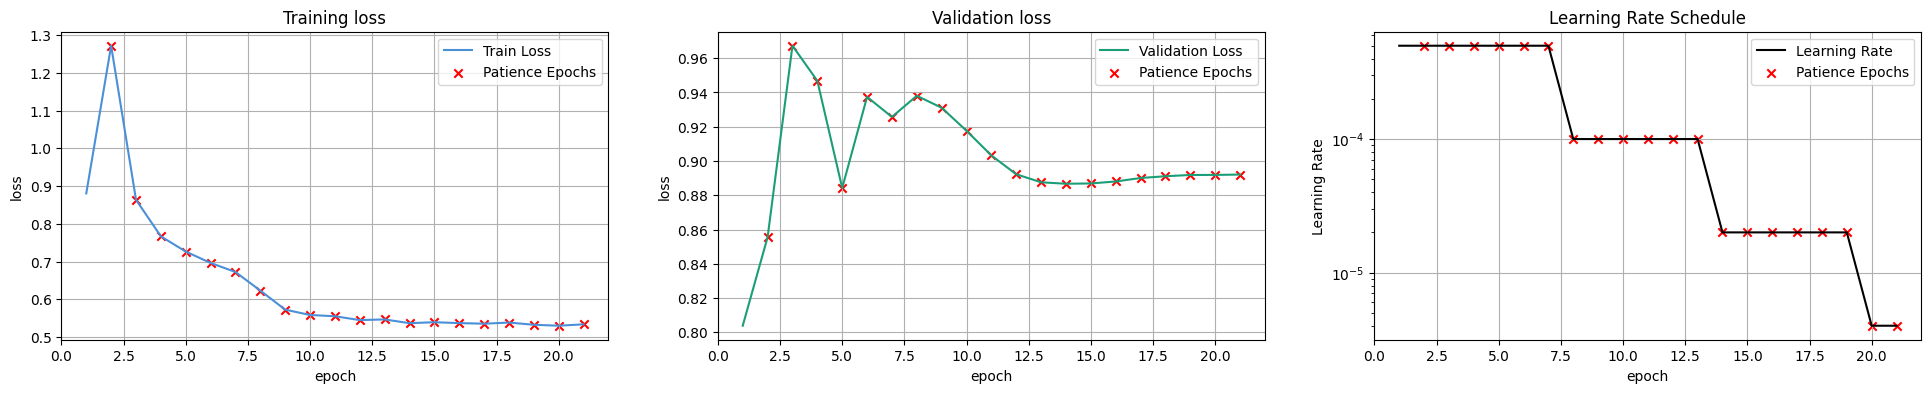

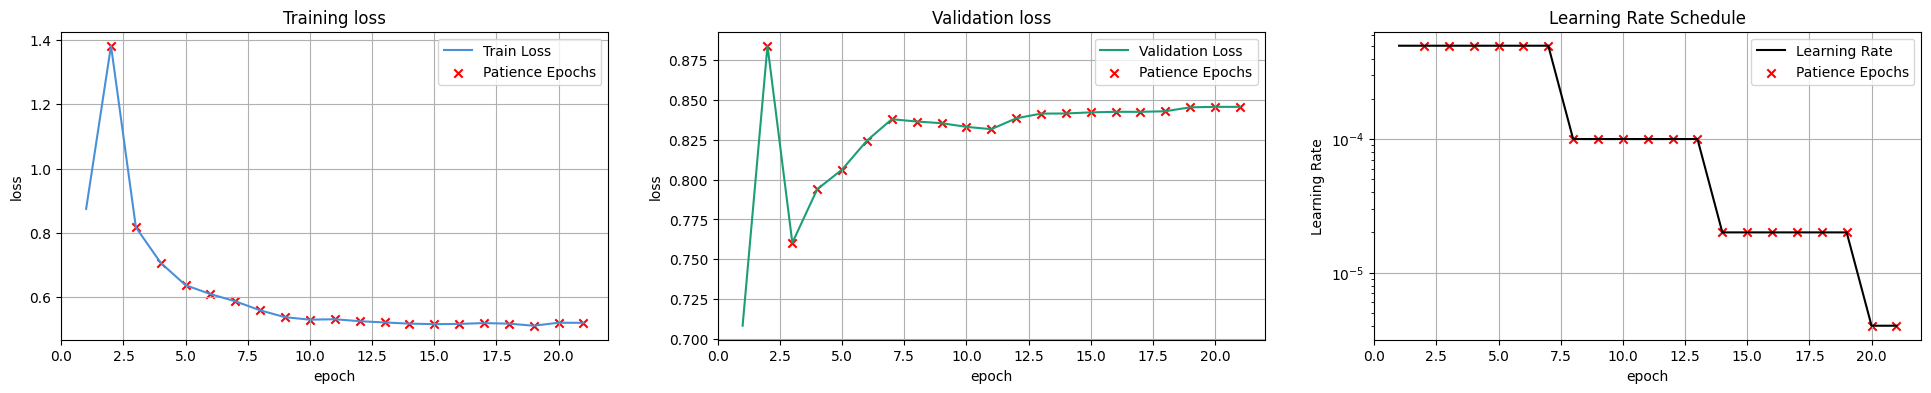

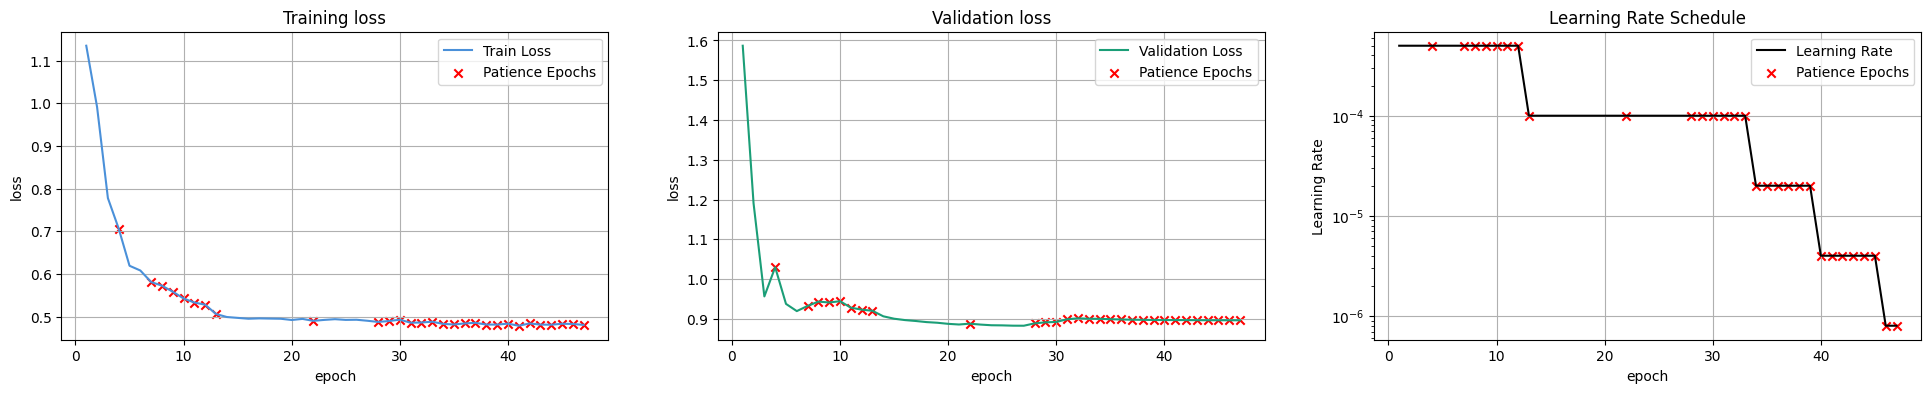

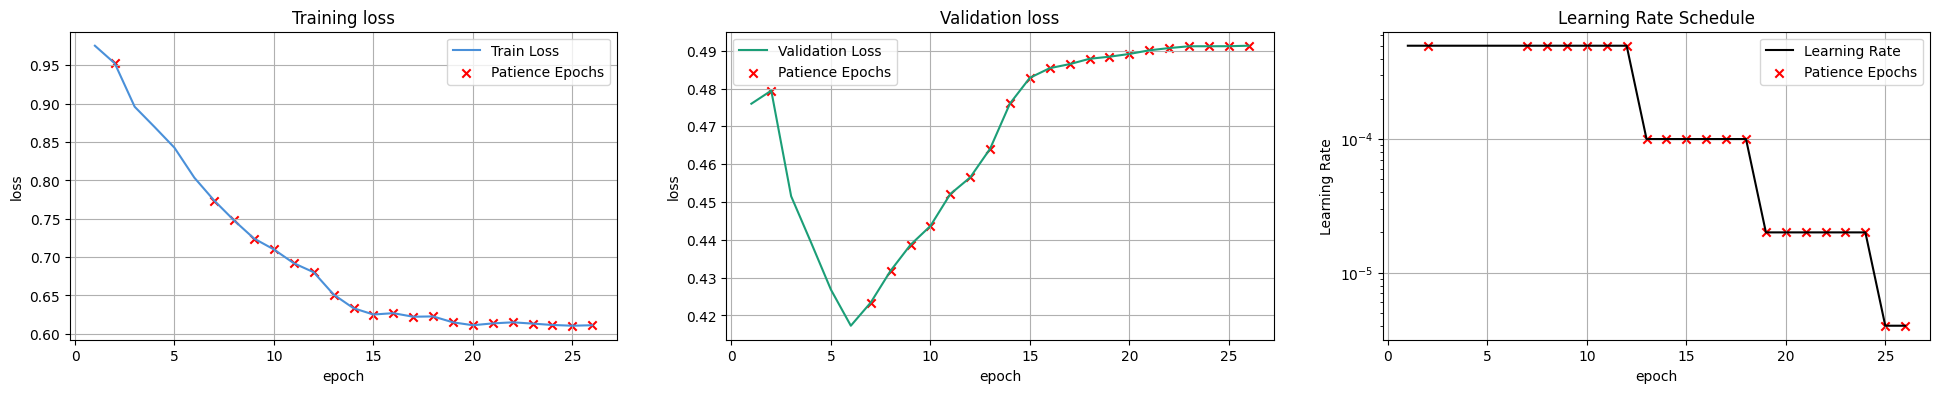

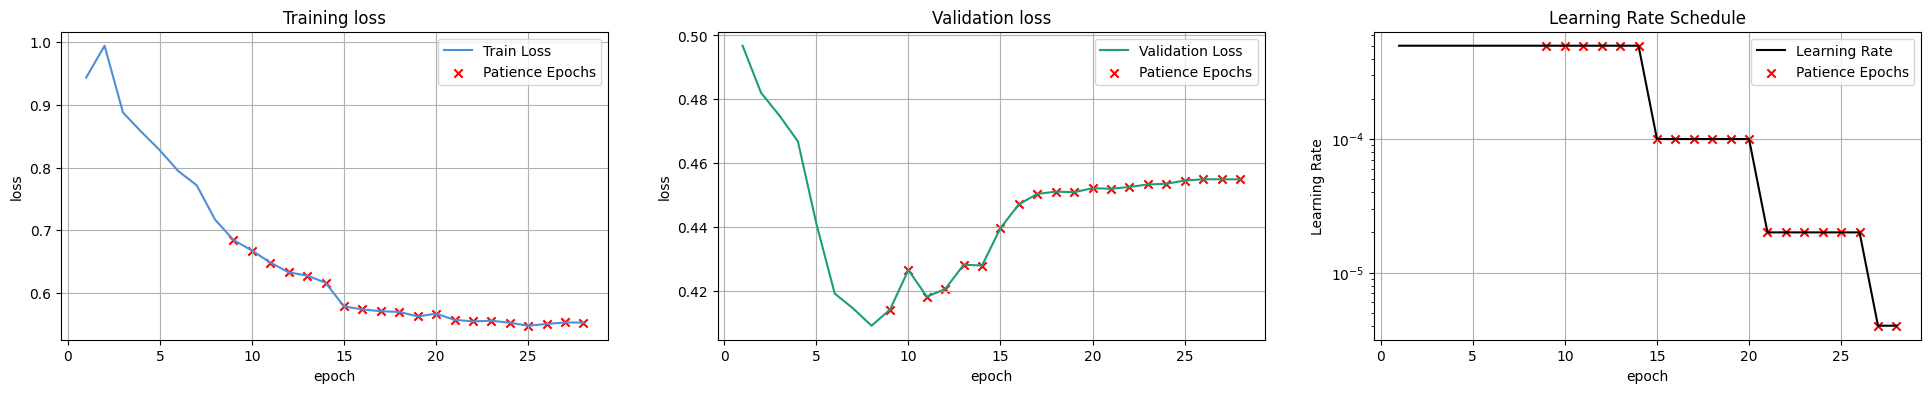

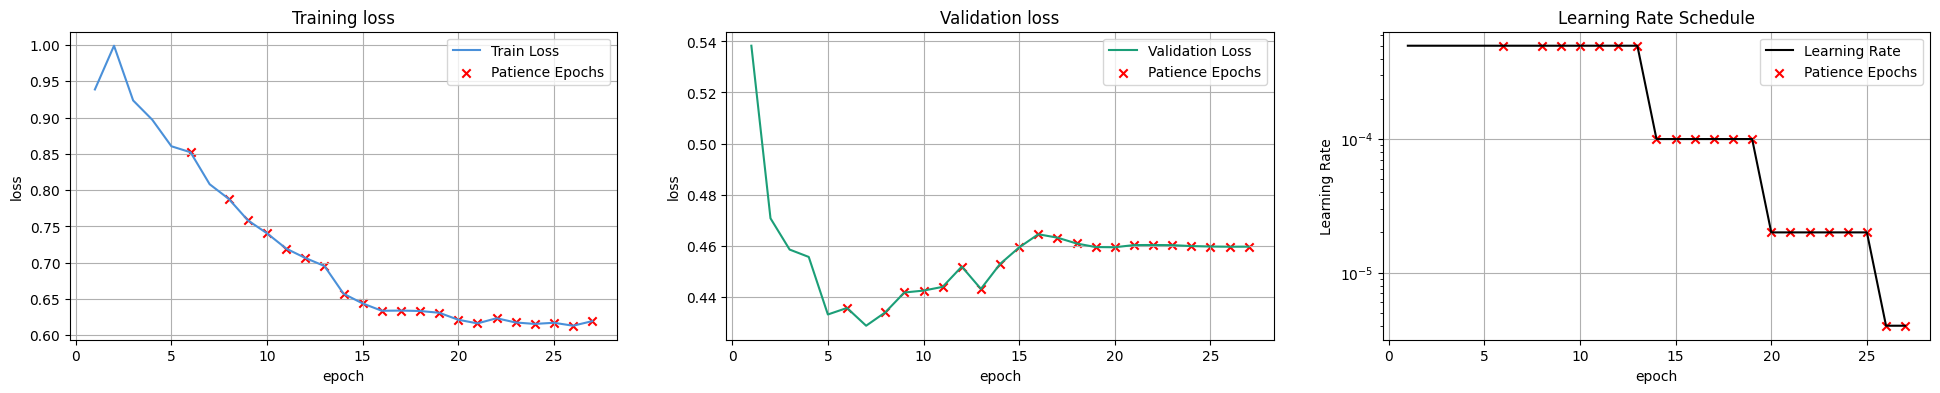

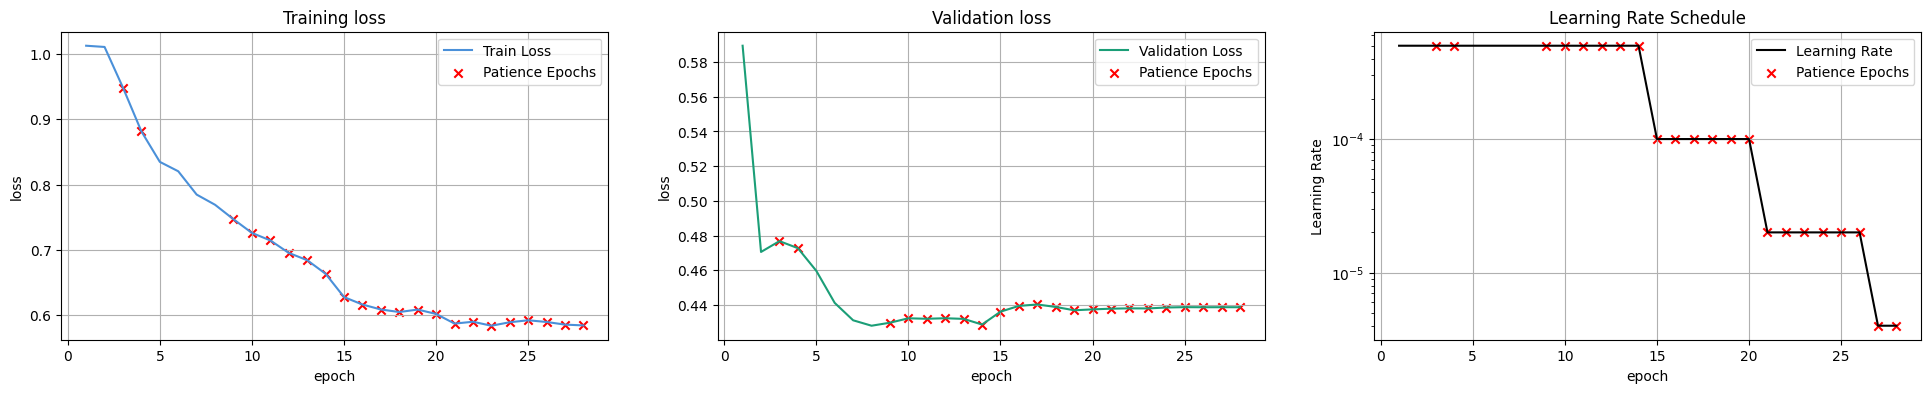

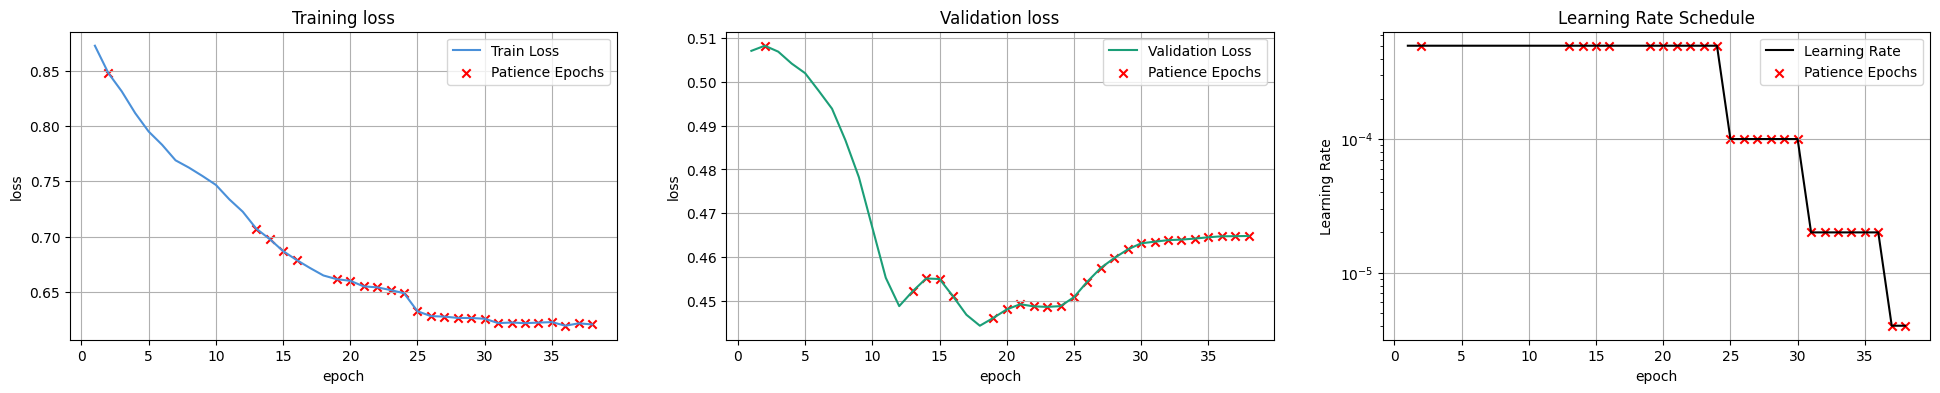

In [3]:
from src.dataloading.dataloaders import BaseLineDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import PersistenceModel, GCN2Model, LSTMModel
from src.evaluation import Evaluator

n_epochs        = 250
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

evaluators = []
for fold in folds:
    data_orch = fold.data_orch

    # ── dataloaders ───────────────────────────────────────────────────────
    baseline_dlm = BaseLineDataLoaderManager(data_orch)
    graph1_dlm   = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph1').build()
    graph2_dlm   = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph2').build()
    graph7_dlm   = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph7').build()
    graph16_dlm  = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph16').build()
    deep_dlm     = DeepDataLoaderManager(data_orch).build()

    f = fold.fold_idx

    # ── models ────────────────────────────────────────────────────────────
    persistence  = PersistenceModel(baseline_dlm,  name=f'persistence_f{f}')

    gcn_g1       = GCN2Model(graph1_dlm,   name=f'gcn_g1_f{f}', verbose = 2)
    gcn_g2       = GCN2Model(graph2_dlm,   name=f'gcn_g2_f{f}', verbose = 2)
    gcn_g7       = GCN2Model(graph7_dlm,   name=f'gcn_g7_f{f}', verbose = 2)
    gcn_g16      = GCN2Model(graph16_dlm,  name=f'gcn_g16_f{f}', verbose = 2)

    lstm         = LSTMModel(deep_dlm,             name=f'lstm_f{f}', verbose = 2)

    # ── set hparams ───────────────────────────────────────────────────────
    for gcn in [gcn_g1, gcn_g2, gcn_g7, gcn_g16]:
        gcn.set_model_hparams()
        gcn.set_global_hparams(**global_hparams)

    lstm.set_model_hparams()
    lstm.set_global_hparams(**global_hparams)

    # ── train + forecast ──────────────────────────────────────────────────
    persistence.forecast()

    for model in [gcn_g1, gcn_g2, gcn_g7, gcn_g16, lstm]:
        model.train()
        model.forecast()

    # ── evaluate ──────────────────────────────────────────────────────────
    evaluator = Evaluator([persistence, gcn_g1, gcn_g2, gcn_g7, gcn_g16, lstm])
    evaluator.add_evaluation(horizon=0, dataset='test')
    evaluators.append(evaluator)

    print(f"fold {f} done")

print(f"\nAll {len(evaluators)} folds evaluated")

In [4]:
import pandas as pd
def spatial_evaluation(evaluators, folds):
    from sklearn.metrics import r2_score, mean_squared_error
    import numpy as np

    records = []

    for fold, evaluator in zip(folds, evaluators):

        # pull denormalised predictions directly from each model
        model_names = list(evaluator.evaluated_models.keys())

        for model_name, model in evaluator.evaluated_models.items():
            try:
                preds = model.predictions.get_preds('test').get(
                    horizon              = 0,
                    is_original          = True,
                    spatially_aggregated = False
                )
            except Exception as e:
                print(f"Could not get predictions for {model_name}: {e}")
                continue

            preds['timestamp'] = pd.to_datetime(preds[evaluator.temporal_col])
            label = model_name.replace(f'_f{fold.fold_idx}', '')

            for timestamp, day_df in preds.groupby('timestamp'):
                y    = day_df['target'].values
                yhat = day_df['pred'].values

                if y.std() == 0:
                    continue

                records.append({
                    'fold':      fold.fold_idx,
                    'timestamp': timestamp,
                    'model':     label,
                    'r2':        r2_score(y, yhat),
                    'rmse':      float(np.sqrt(mean_squared_error(y, yhat))),
                })

    df = pd.DataFrame(records)

    print("\n── Mean spatial R² per model across folds ───────────────────")
    print(df.groupby('model')['r2'].mean().sort_values(ascending=False).round(3))

    print("\n── Mean spatial RMSE (relative to persistence) ──────────────")
    rmse_means = df.groupby('model')['rmse'].mean()
    pers_rmse  = rmse_means.get('persistence', None)
    if pers_rmse:
        print((rmse_means / pers_rmse - 1).sort_values().round(3).to_string() + 
              "  (negative = better than persistence)")
    else:
        print(rmse_means.sort_values().round(3))

    return df

results = spatial_evaluation(evaluators, folds)


── Mean spatial R² per model across folds ───────────────────
model
persistence   -4.651
gcn_g16       -5.420
gcn_g1        -5.431
gcn_g7        -5.788
lstm          -6.004
gcn_g2        -7.052
Name: r2, dtype: float64

── Mean spatial RMSE (relative to persistence) ──────────────
model
gcn_g16       -0.093
gcn_g1        -0.087
gcn_g7        -0.069
gcn_g2        -0.056
lstm          -0.039
persistence    0.000  (negative = better than persistence)


In [10]:
def spatial_evaluation_per_fold(evaluators, folds):
    from sklearn.metrics import r2_score, mean_squared_error
    import numpy as np

    fold_records = []

    for fold, evaluator in zip(folds, evaluators):
        day_records = []

        for model_name, model in evaluator.evaluated_models.items():
            try:
                preds = model.predictions.get_preds('test').get(
                    horizon=0, is_original=True, spatially_aggregated=False
                )
            except Exception as e:
                print(f"fold {fold.fold_idx} {model_name}: {e}")
                continue

            preds['timestamp'] = pd.to_datetime(preds[evaluator.temporal_col])
            label = model_name.replace(f'_f{fold.fold_idx}', '')

            for timestamp, day_df in preds.groupby('timestamp'):
                y    = day_df['target'].values
                yhat = day_df['pred'].values
                if y.std() == 0:
                    continue
                day_records.append({
                    'model': label,
                    'timestamp': timestamp,
                    'r2':   r2_score(y, yhat),
                    'rmse': float(np.sqrt(mean_squared_error(y, yhat))),
                })

        if not day_records:
            continue

        day_df    = pd.DataFrame(day_records)
        fold_summary = day_df.groupby('model').agg(
            r2_mean   = ('r2',   'mean'),
            r2_std    = ('r2',   'std'),
            rmse_mean = ('rmse', 'mean'),
        ).round(3)

        fold_summary['fold']     = fold.fold_idx
        fold_summary['min_date'] = fold.metadata['min_date']
        fold_summary['max_date'] = fold.metadata['max_date']
        fold_records.append(fold_summary.reset_index())

    all_folds = pd.concat(fold_records, ignore_index=True)

    # ── print per-fold R² table ───────────────────────────────────────────
    pivot = all_folds.pivot_table(
        index   = 'model',
        columns = 'fold',
        values  = 'r2_mean'
    ).round(3)

    print("\n── Spatial R² per model per fold ────────────────────────────")
    print(pivot.to_string())

    print("\n── Mean R² across folds ─────────────────────────────────────")
    print(pivot.mean(axis=1).sort_values(ascending=False).round(3))

    print("\n── Fold date ranges ─────────────────────────────────────────")
    for fold in folds:
        print(f"  fold {fold.fold_idx}: {fold.metadata['min_date']} → {fold.metadata['max_date']}")

    return all_folds, pivot

all_folds_df, pivot = spatial_evaluation_per_fold(evaluators, folds)


── Spatial R² per model per fold ────────────────────────────
fold             0      1      2      3      4       5      6       7
model                                                                
gcn_g1       0.056 -0.388 -0.831 -0.442 -0.866  -2.279 -1.044 -42.607
gcn_g16      0.024 -0.403 -0.672 -0.199 -0.805  -2.146 -1.252 -42.906
gcn_g2       0.034 -0.394 -0.426 -0.194 -0.813  -2.269 -2.322 -56.649
gcn_g7       0.019 -0.433 -0.861 -0.190 -0.592  -2.378 -1.494 -45.695
lstm         0.003 -0.330 -0.101 -0.714 -0.621  -3.507 -0.780 -47.520
persistence -0.600  0.249 -0.556 -1.395 -0.585 -26.247 -1.948  -6.354

── Mean R² across folds ─────────────────────────────────────
model
persistence   -4.680
gcn_g16       -6.045
gcn_g1        -6.050
gcn_g7        -6.453
lstm          -6.696
gcn_g2        -7.879
dtype: float64

── Fold date ranges ─────────────────────────────────────────
  fold 0: 2021-07-01 → 2021-09-28
  fold 1: 2021-07-29 → 2021-10-26
  fold 2: 2021-08-26 → 2021-11-23
  

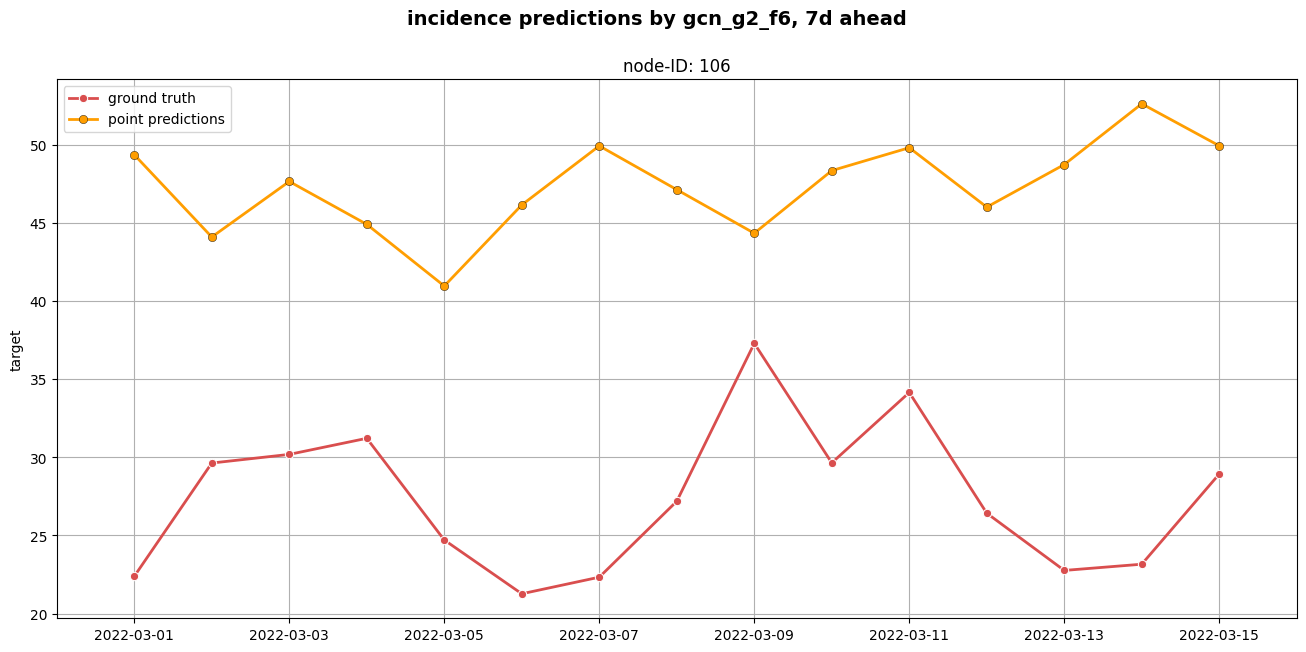

In [26]:
list(evaluators[6].evaluated_models.values())[2].show_forecasts(106).show()

In [11]:
# RMSE relative to persistence per fold — drop fold 7
rmse_pivot = all_folds_df.pivot_table(
    index   = 'model',
    columns = 'fold',
    values  = 'rmse_mean'
).round(3)

# compute relative to persistence
pers_row = rmse_pivot.loc['persistence']
relative = (rmse_pivot / pers_row - 1).drop('persistence').round(3)

# drop fold 7
relative = relative.drop(columns=7, errors='ignore')

print("\n── RMSE relative to persistence (excl. fold 7) ─────────────")
print(relative.to_string())
print("\n── Mean across folds ────────────────────────────────────────")
print(relative.mean(axis=1).sort_values())


── RMSE relative to persistence (excl. fold 7) ─────────────
fold         0      1      2      3      4      5      6
model                                                   
gcn_g1  -0.225  0.367  0.085 -0.262  0.120 -0.218 -0.215
gcn_g16 -0.212  0.373  0.038 -0.292  0.104 -0.232 -0.179
gcn_g2  -0.217  0.368 -0.039 -0.308  0.106 -0.220 -0.094
gcn_g7  -0.210  0.388  0.094 -0.294  0.038 -0.212 -0.132
lstm    -0.205  0.338 -0.178 -0.193  0.045 -0.123 -0.225

── Mean across folds ────────────────────────────────────────
model
lstm      -0.077286
gcn_g2    -0.057714
gcn_g16   -0.057143
gcn_g1    -0.049714
gcn_g7    -0.046857
dtype: float64


In [12]:
fold = folds[0]
evaluator = evaluators[0]

for model_name, model in evaluator.evaluated_models.items():
    try:
        preds = model.predictions.get_preds('test').get(0, True, False)
        day   = preds[preds['timestamp'] == preds['timestamp'].unique()[0]]
        print(f"{model_name:20s}  target_std={day['target'].std():.3f}  pred_std={day['pred'].std():.3f}  ratio={day['pred'].std()/day['target'].std():.2f}")
    except:
        pass

persistence_f0        target_std=0.840  pred_std=0.951  ratio=1.13
gcn_g1_f0             target_std=0.840  pred_std=0.136  ratio=0.16
gcn_g2_f0             target_std=0.840  pred_std=0.144  ratio=0.17
gcn_g7_f0             target_std=0.840  pred_std=0.139  ratio=0.16
gcn_g16_f0            target_std=0.840  pred_std=0.119  ratio=0.14
lstm_f0               target_std=0.840  pred_std=0.156  ratio=0.19


In [6]:
fold_df = folds[0].data_orch.data_final.data
train_df = fold_df[fold_df['train']]

# spatial std vs temporal std of normalised target
spatial_std  = train_df.groupby('timestamp')['target_lead7'].std().mean()
temporal_std = train_df.groupby('node')['target_lead7'].std().mean()
print(f"Mean spatial std (across nodes per timestep):  {spatial_std:.4f}")
print(f"Mean temporal std (across time per node):      {temporal_std:.4f}")
print(f"Ratio spatial/temporal: {spatial_std/temporal_std:.3f}")

Mean spatial std (across nodes per timestep):  0.6621
Mean temporal std (across time per node):      0.9524
Ratio spatial/temporal: 0.695


In [7]:
fold_df = folds[0].data_orch.data_final.data
test_df = fold_df[fold_df['test']]
first_day = test_df[test_df['timestamp'] == test_df['timestamp'].min()]

lag_col = f"{folds[0].epiconfig.lag_column}_lag0"
if lag_col in first_day.columns:
    print(f"\nLag feature spatial std on test day 1: {first_day[lag_col].std():.4f}")
    print(first_day[lag_col].describe())


Lag feature spatial std on test day 1: 0.7010
count    342.000000
mean      -0.210435
std        0.701025
min       -1.310821
25%       -0.723428
50%       -0.178778
75%        0.318953
max        2.182034
Name: incidence_lag0, dtype: float64


In [8]:
import pandas as pd

# collect CCC per model across all folds
records = []
for fold, evaluator in zip([folds[0]], evaluators):
    metrics = evaluator.data_compilation.get_data(0, 'test')['metrics'].copy()
    metrics['fold']     = fold.fold_idx
    metrics['min_date'] = fold.metadata['min_date']
    metrics['max_date'] = fold.metadata['max_date']
    records.append(metrics)

all_metrics = pd.concat(records, ignore_index=True)
all_metrics['model'] = all_metrics['model'].astype(str).str.replace(r'_f\d+$', '', regex=True)

# summary: mean CCC per model across folds
print(all_metrics.groupby('model')['ccc'].mean().sort_values(ascending=False))

model
persistence    0.029009
gcn_g1         0.024567
gcn_g16        0.016872
lstm           0.016055
gcn_g7         0.013453
gcn_g2         0.009641
Name: ccc, dtype: float64


count    35226.000000
mean         0.383588
std          1.062758
min         -3.519963
25%         -0.386184
50%          0.392791
75%          1.131351
max          4.991729
Name: target_lead7, dtype: float64
Test rows: 5130
count    5130.000000
mean        1.139636
std         0.650851
min        -3.519963
25%         0.771150
50%         1.121347
75%         1.535020
max         3.455776
Name: target_lead7, dtype: float64


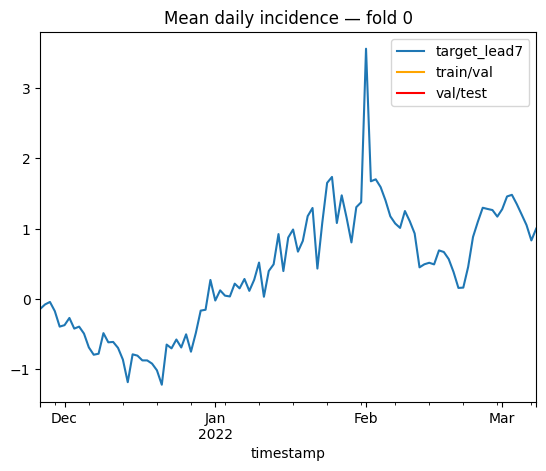

In [27]:
fold = folds[6]
final_df = fold.data_orch.data_final.data

# what does the target distribution look like?
print(final_df['target_lead7'].describe())

# is there actual variation in the test period?
test_mask = final_df['test']
print(f"Test rows: {test_mask.sum()}")
print(final_df[test_mask]['target_lead7'].describe())

# plot national incidence over time
import matplotlib.pyplot as plt
national = final_df.groupby('timestamp')['target_lead7'].mean()
national.plot(title='Mean daily incidence — fold 0')
plt.axvline(pd.Timestamp('2021-08-23'), color='orange', label='train/val')
plt.axvline(pd.Timestamp('2021-08-30'), color='red', label='val/test')
plt.legend()
plt.show()

In [14]:
evaluator

<Evaluator(models: ['persistence_f0', 'gcn_g1_f0', 'gcn_g2_f0', 'gcn_g7_f0', 'gcn_g16_f0', 'lstm_f0'],
	data_compilation: <EvaluationPredictionsCompilation({'test': ['horizon_0']})>
	metric_calculator: <PointRegressionMetricsCalculator(supported_metrics: ['bcf', 'ccc', 'mae', 'mape', 'mbe', 'mse', 'pearson', 'r2', 'rmse', 'smape', 'spearman', 'vr'])>)>